**Описание проекта**

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.

«В один клик» — современная компания, поэтому её руководство хочет принимать решения только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, в котором нам предложено место стажера. Отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

**Описание данных**

•	`id` — номер покупателя в корпоративной базе данных.

•	`Покупательская активность` — рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».

•	`Тип сервиса` — уровень сервиса, например «премиум» и «стандарт».

•	`Разрешить сообщать` — информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.

•	`Маркет_актив_6_мес` — среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев.

•	`Маркет_актив_тек_мес` — количество маркетинговых коммуникаций в текущем месяце.

•	`Длительность` — значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.

•	`Акционные_покупки` — среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.

•	`Популярная_категория` — самая популярная категория товаров у покупателя за последние 6 месяцев.

•	`Средний_просмотр_категорий_за_визит` — показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.

•	`Неоплаченные_продукты_штук_квартал` — общее число неоплаченных товаров в корзине за последние 3 месяца.

•	`Ошибка_сервиса` — число сбоев, которые коснулись покупателя во время посещения сайта.

•	`Страниц_за_визит` — среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.

•	`Период` — название периода, во время которого зафиксирована выручка/ общее время, которое покупатель провёл на сайте.

•	`Выручка` — сумма выручки за период.

•	`минут` — значение времени, проведённого на сайте, в минутах.

•	`Прибыль` — значение прибыли, которую получает магазин от продаж каждому покупателю за последние 3 месяца.


## Загрузка данных

In [1]:
# установим, обновим необходимые библиотеки
!pip install phik -q
!pip install -q --upgrade shap matplotlib
!pip install -q --upgrade scikit-learn

In [2]:
# импортируем все необходимые библиотеки, метрики, функции, модели
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

import statsmodels as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

import sklearn
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV

import shap
import phik
from phik import phik_matrix
from phik.report import plot_correlation_matrix

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [4]:
# выгружаем файлы с данными и сохраняем в датафреймы
try:
    market_buyers = pd.read_csv('datasets/market_file.csv')
    market_money = pd.read_csv('datasets/market_money.csv')
    market_time = pd.read_csv('datasets/market_time.csv')
    profit = pd.read_csv('datasets/money.csv', sep=';', decimal = ',')
except:
    market_buyers = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')
    market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')
    market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv')
    profit = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal = ',')

In [5]:
# выведем первый строки и посмотрим общую информацию
display(market_buyers.head())
market_buyers.info()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   Покупательская активность            1300 non-null   object 
 2   Тип сервиса                          1300 non-null   object 
 3   Разрешить сообщать                   1300 non-null   object 
 4   Маркет_актив_6_мес                   1300 non-null   float64
 5   Маркет_актив_тек_мес                 1300 non-null   int64  
 6   Длительность                         1300 non-null   int64  
 7   Акционные_покупки                    1300 non-null   float64
 8   Популярная_категория                 1300 non-null   object 
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  Ошибка_сервиса                

In [6]:
# выведем первый строки и посмотрим общую информацию
display(market_money.head())
market_money.info()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   Период   3900 non-null   object 
 2   Выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB


In [7]:
# выведем первый строки и посмотрим общую информацию
display(market_time.head())
market_time.info()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [8]:
# выведем первый строки и посмотрим общую информацию
display(profit.head())
profit.info()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


**Вывод:**

Мы выгрузили четыре файла с таблицами и сохранили данные каждой таблицы в отдельные датафреймы. Выведенная общая информация по таблицам показывает, что пропусков в данных нет, и что в столбце `Прибыль` в датафрейме `profit` неверный тип данных из-за неверного формата данных. Мы исправили разделитель десятичных значений с запятой на точку, поменяв при загрузке файла праматер `decimal`, после чего получили верный тип данных в столбце `Прибыль`.

## Предобработка данных 

In [9]:
# сделаем необходимые переименования столбцов в датафреймах, приведем их к змеиному регистру
market_buyers.columns = [re.sub(r'(?<!^)(?=[А-Я])|(\s+)', '_', i).lower() for i in market_buyers.columns]
market_money.columns = [i.lower() for i in market_money.columns]
market_time.columns = [i.lower() for i in market_time.columns]
profit.columns = [i.lower() for i in profit.columns]
market_buyers.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


In [10]:
# проверка наличия полных дублей
print(market_buyers.duplicated().sum())
print(market_money.duplicated().sum())
print(market_time.duplicated().sum())
print(profit.duplicated().sum())

0
0
0
0


In [11]:
# проверка наличия дублей по 'id' и по 'id'+'период'
print(market_buyers['id'].duplicated().sum())
print(profit['id'].duplicated().sum())
print(market_money[['id', 'период']].duplicated().sum())
print(market_time[['id', 'период']].duplicated().sum())

0
0
0
0


In [12]:
# проверка на наличие неявных дублей, ошибок в категориальных данных
print(market_buyers['покупательская_активность'].unique())
print(market_buyers['тип_сервиса'].unique())
print(market_buyers['разрешить_сообщать'].unique())
print(market_buyers['популярная_категория'].unique())

['Снизилась' 'Прежний уровень']
['премиум' 'стандартт' 'стандарт']
['да' 'нет']
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']


In [13]:
# исправление явных опечаток
market_buyers.replace({'тип_сервиса': {'стандартт': 'стандарт'}}, inplace=True)
market_buyers.replace({'популярная_категория': {'Косметика и аксесуары': 'Косметика и аксессуары'}}, inplace=True)

In [14]:
# проверка на наличие неявных дублей, ошибок в категориальных данных
market_money['период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

In [15]:
# исправление
market_money.replace({'период': {'препредыдущий_месяц': 'предпредыдущий_месяц'}}, inplace=True)

In [16]:
# проверка на наличие неявных дублей, 
market_time['период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [17]:
# исправление
market_time.replace({'период': {'предыдцщий_месяц': 'предыдущий_месяц'}}, inplace=True)

**Выводы:**

Мы привели названия всех столбцов к единому стандарту с помощью змеиного регистра, но оставили русскоязычные названия для упрощения понимания. Мы убедились, что тип данных задан правильно для всех столбцов ещё по информации, выведенной на предыдущем этапе. Также мы провели проверку данных на наличие явных и неявных дублей. Явных дублей не было обнаружено. А для устранения неявных и для удобства дальнейшей работы мы исправили опечатки. 

## Исследовательский анализ данных

In [18]:
# ищем покупателей, которые принесли нулевую выручку хотя бы в одном из 3 месяцев и и создаем лист с 'id' таких покупателей
null_purchase_id = market_money.query('выручка == 0')['id'].unique()
null_purchase_id

array([215348, 215357, 215359])

In [19]:
# перезаписываем датафреймы с данными, удаляя строки 'id' покупателей с нулевыми тратами хотя бы в одном месяце из 3-х
market_money = market_money.query('id not in @null_purchase_id').reset_index(drop=True)
market_buyers = market_buyers.query('id not in @null_purchase_id').reset_index(drop=True)
market_time = market_time.query('id not in @null_purchase_id').reset_index(drop=True)
profit = profit.query('id not in @null_purchase_id').reset_index(drop=True)

In [20]:
market_buyers.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4


In [21]:
# выводим описательную статистику по количественному признаку 'маркет_актив_6_мес'
market_buyers['маркет_актив_6_мес'].describe()

count    1297.000000
mean        4.254433
std         1.015618
min         0.900000
25%         3.700000
50%         4.200000
75%         4.900000
max         6.600000
Name: маркет_актив_6_мес, dtype: float64

In [22]:
 # создадим функцию для построения графиков для количественных признаков
def num_feature_plots(data, feature, bins, name):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16,7))
    fig.suptitle(name, fontsize=14)
    
    # строим диаграмму размаха
    sns.set_style("whitegrid")
    sns.boxplot(ax=axes[0], data = data, y = feature)
    axes[0].set_title(f'Диаграмма размаха для признака: {feature}')
    axes[0].set_ylabel(f'{feature}')
    
    # строим гистрограмму
    sns.histplot(ax=axes[1], data=data[feature], bins=bins)
    axes[1].set_title(f'Распределение значений признака: {feature}')
    axes[1].set_xlabel(f'{feature}')
    axes[1].set_ylabel('Частоты')
    plt.show()

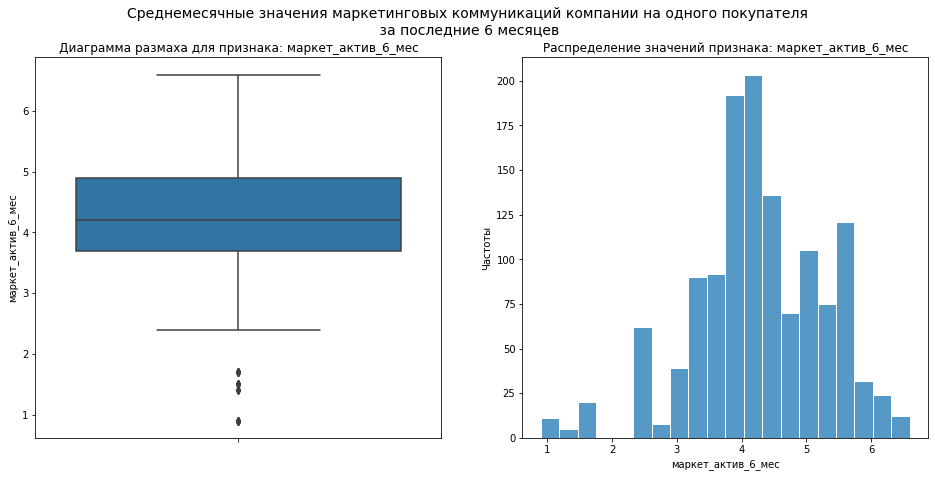

In [23]:
# построим графики для признака 'маркет_актив_6_мес'
num_feature_plots(data=market_buyers, feature='маркет_актив_6_мес', bins=20,
                  name = 'Cреднемесячные значения маркетинговых коммуникаций компании на одного покупателя\n за последние 6 месяцев')

Распределение по признаку отличается от нормального, есть небольшое кол-во выбросов.

In [24]:
# выводим описательную статистику по количественному признаку 'маркет_актив_тек_мес'
market_buyers['маркет_актив_тек_мес'].describe()

count    1297.000000
mean        4.009252
std         0.696048
min         3.000000
25%         4.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: маркет_актив_тек_мес, dtype: float64

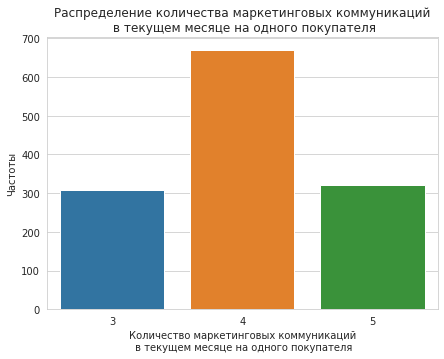

In [25]:
# строим гистрограмму по количественному признаку 'маркет_актив_тек_мес'
plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")
sns.countplot(data=market_buyers, x='маркет_актив_тек_мес')
plt.title('Распределение количества маркетинговых коммуникаций\n в текущем месяце на одного покупателя')
plt.xlabel('Количество маркетинговых коммуникаций\n в текущем месяце на одного покупателя')
plt.ylabel('Частоты')
plt.show()

In [26]:
# выводим описательную статистику по количественному признаку 'длительность'
market_buyers['длительность'].describe()

count    1297.000000
mean      602.993832
std       249.101456
min       121.000000
25%       410.000000
50%       607.000000
75%       806.000000
max      1079.000000
Name: длительность, dtype: float64

Всего 3 значения у признака: 3, 4, 5. Наиболее часто встречается значение 4, медиана приходится на значение 4.

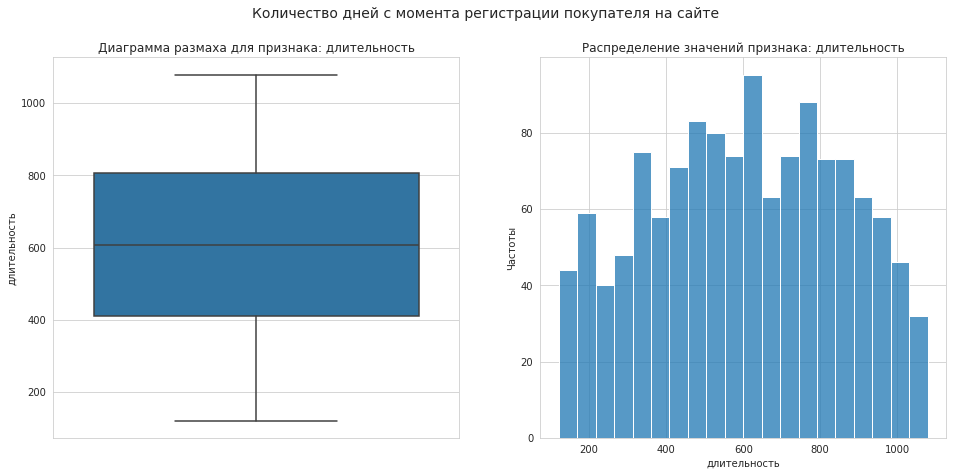

In [27]:
# построим графики для признака 'длительность'
num_feature_plots(data=market_buyers, feature='длительность', bins=20,
                  name = 'Количество дней с момента регистрации покупателя на сайте')

Распределение по признаку близко к нормальному, выбросов нет. Среднее значение - 603, медианное - 607

In [28]:
# выводим описательную статистику по количественному признаку 'акционные_покупки'
market_buyers['акционные_покупки'].describe()

count    1297.000000
mean        0.320547
std         0.249657
min         0.110000
25%         0.170000
50%         0.240000
75%         0.300000
max         0.990000
Name: акционные_покупки, dtype: float64

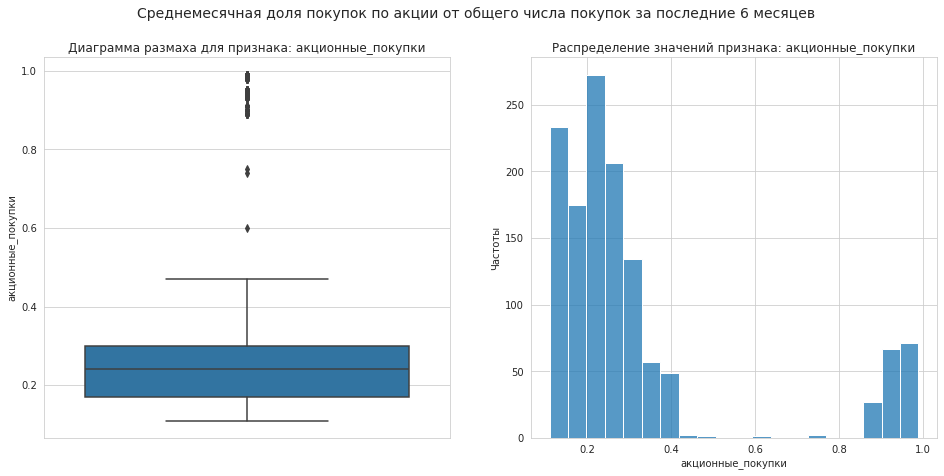

In [29]:
# построим графики для признака 'акционные_покупки'
num_feature_plots(data=market_buyers, feature='акционные_покупки', bins=20,
                  name = 'Cреднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев')

Распределение сильно отличается от нормального, вершина (наиболее частые значения) смещена ближе к 0, медиана приходится на 0.24, а ближе к 1 наблюдается сравнительно много выбросов (покупатели с долей акционных покупок более 0.8).

In [30]:
# выводим описательную статистику по количественному признаку 'средний_просмотр_категорий_за_визит'
market_buyers['средний_просмотр_категорий_за_визит'].describe()

count    1297.000000
mean        3.267540
std         1.354623
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: средний_просмотр_категорий_за_визит, dtype: float64

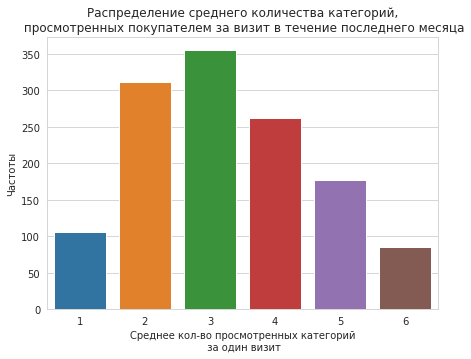

In [31]:
# строим гистрограмму по количественному признаку 'средний_просмотр_категорий_за_визит'
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))
sns.countplot(data=market_buyers, x='средний_просмотр_категорий_за_визит')
plt.title('Распределение среднего количества категорий,\n просмотренных покупателем за визит в течение последнего месяца')
plt.xlabel('Среднее кол-во просмотренных категорий\n за один визит')
plt.ylabel('Частоты')
plt.show()

Значения признака - целые числа от 1 до 6 включительно. Наиболее часто встречается значение 3, медиана приходится на значение 3.

In [32]:
# выводим описательную статистику по количественному признаку 'неоплаченные_продукты_штук_квартал'
market_buyers['неоплаченные_продукты_штук_квартал'].describe()

count    1297.000000
mean        2.841172
std         1.973451
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64

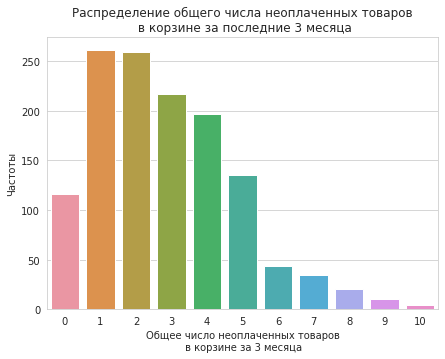

In [33]:
# строим гистрограмму по количественному признаку 'неоплаченные_продукты_штук_квартал'
plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")
sns.countplot(data=market_buyers, x='неоплаченные_продукты_штук_квартал')
plt.title('Распределение общего числа неоплаченных товаров\n в корзине за последние 3 месяца')
plt.xlabel('Общее число неоплаченных товаров\n в корзине за 3 месяца')
plt.ylabel('Частоты')
plt.show()

Распределение отлично от нормального. Значения признака - целые числа от 0 до 10 включительно. Наиболее часты значения 1 и 2, медиана приходится на значение 3.

In [34]:
# выводим описательную статистику по количественному признаку 'ошибка_сервиса'
market_buyers['ошибка_сервиса'].describe()

count    1297.000000
mean        4.184271
std         1.950973
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max         9.000000
Name: ошибка_сервиса, dtype: float64

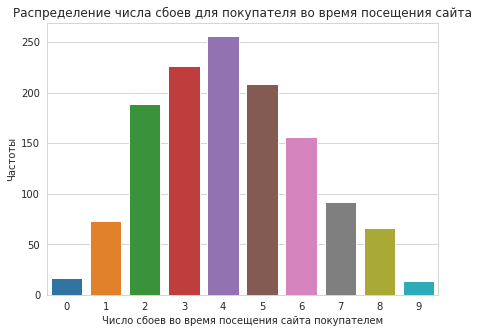

In [35]:
# строим гистрограмму по количественному признаку 'ошибка_сервиса'
plt.figure(figsize=(7, 5))
sns.set_style("whitegrid")
sns.countplot(data=market_buyers, x='ошибка_сервиса')
plt.title('Распределение числа сбоев для покупателя во время посещения сайта')
plt.xlabel('Число сбоев во время посещения сайта покупателем')
plt.ylabel('Частоты')
plt.show()

Распределение по признаку близко к нормальному. Значения признака - целые числа от 0 до 9 включительно. Мода и медиана приходится на значение 4.

In [36]:
# выводим описательную статистику по количественному признаку 'страниц_за_визит'
market_buyers['страниц_за_визит'].describe()

count    1297.000000
mean        8.186584
std         3.977061
min         1.000000
25%         5.000000
50%         8.000000
75%        11.000000
max        20.000000
Name: страниц_за_визит, dtype: float64

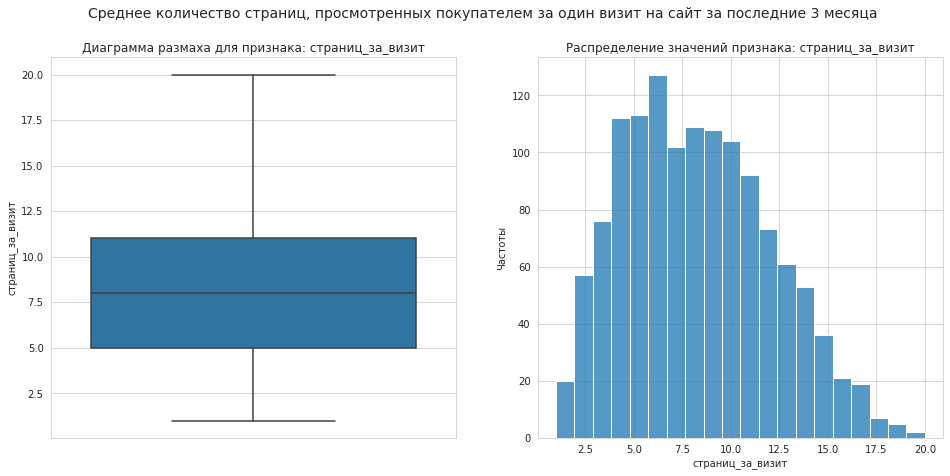

In [37]:
# построим графики для признака 'страниц_за_визит'
num_feature_plots(data=market_buyers, feature='страниц_за_визит', bins=20,
                  name = 'Среднее количество страниц, просмотренных покупателем за один визит на сайт за последние 3 месяца')

Распределение по признаку отличается от нормального. Значения признака - целые числа от 1 до 20 включительно. Мода приходится на 6, медиана на 8.

In [38]:
# выводим описательную статистику по количественному признаку 'прибыль'
profit['прибыль'].describe()

count    1297.000000
mean        3.997610
std         1.010813
min         0.860000
25%         3.300000
50%         4.040000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

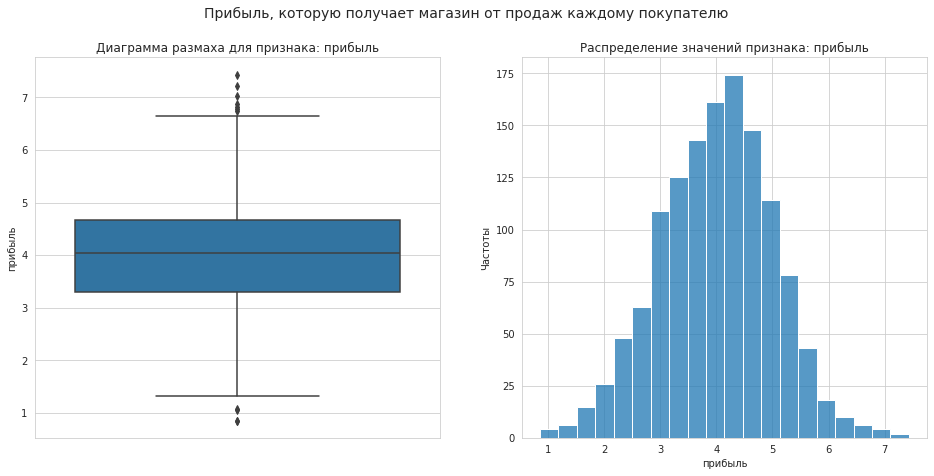

In [39]:
# построим графики для признака 'прибыль'
num_feature_plots(data=profit, feature='прибыль', bins=20,
                  name = 'Прибыль, которую получает магазин от продаж каждому покупателю')

Распределение по признаку близко к нормальному. Есть незначиельное число выбросов со значениями менее 1 и более 6.5. Медианное значение составляет 4.04.

In [40]:
# создадим новый датафрейм с отдельным столбцом для выручки за каждый из 3-х месяцев
market_money_by_period = market_money.pivot_table(index='id', columns='период', values='выручка').reset_index()
market_money_by_period.columns = ['id', 'выручка_за_предпредыдущий_месяц', 'выручка_за_предыдущий_месяц', 'выручка_за_текущий_месяц']
market_money_by_period.head()

,id,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц
0,215349,4472.0,5216.0,4971.6
1,215350,4826.0,5457.5,5058.4
2,215351,4793.0,6158.0,6610.4
3,215352,4594.0,5807.5,5872.5
4,215353,5124.0,4738.5,5388.5


In [41]:
# описательная статистика по количественному признаку 'выручка_за_текущий_месяц' 
market_money_by_period['выручка_за_текущий_месяц'].describe()

count      1297.000000
mean       5316.449268
std        2942.469139
min        2758.700000
25%        4706.600000
50%        5180.300000
75%        5761.300000
max      106862.200000
Name: выручка_за_текущий_месяц, dtype: float64

In [42]:
# выявляем аномально высокие значения
display(market_money_by_period.query('выручка_за_текущий_месяц > 10000'))

,id,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц
29,215380,5051.0,6077.0,106862.2


In [43]:
# заменяем аномалбное значение на среднее значение выручки за текущий месяц
market_money_by_period.iloc[29, 3] = market_money_by_period['выручка_за_текущий_месяц'].median()

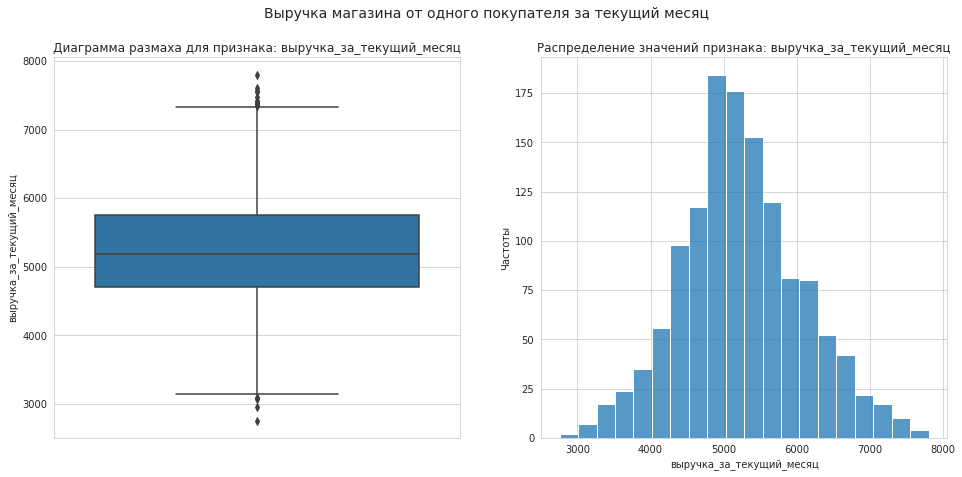

In [44]:
# построим графики для признака 'выручка_за_текущий_месяц'
num_feature_plots(data=market_money_by_period, feature='выручка_за_текущий_месяц', bins=20,
                  name = 'Выручка магазина от одного покупателя за текущий месяц')

Обнаружилось одно аномально высокое значение выручки для одного из покупателей за текущий месяц. Мы заменили аномально высокое значение на среднее по текущему месяцу. В выборке также есть выбросы, несильно отклоняющиеся от крайних точек усов на диаграмме размаха. Распределение близко к нормальному, медианное значение приходится на 5180. 

In [45]:
# описательная статистика по количественному признаку 'выручка_за_предыдущий_месяц' 
market_money_by_period['выручка_за_предыдущий_месяц'].describe()

count    1297.000000
mean     4948.339630
std       701.228571
min      2890.000000
25%      4498.500000
50%      5005.500000
75%      5409.000000
max      6869.500000
Name: выручка_за_предыдущий_месяц, dtype: float64

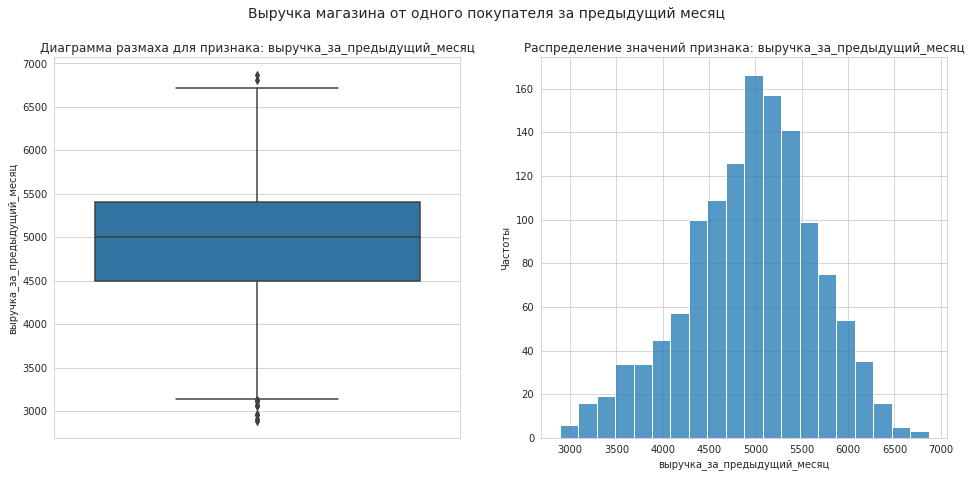

In [46]:
# построим графики для признака 'выручка_за_предыдущий_месяц'
num_feature_plots(data=market_money_by_period, feature='выручка_за_предыдущий_месяц', bins=20,
                  name = 'Выручка магазина от одного покупателя за предыдущий месяц')

Среди значений признака есть совсем немного выбросов, незначительно отклоняющихся от крайних точек усов на диаграмме размаха. Распределение отличается от нормального, вершина смещена вправо, медианное значение приходится на 5005, среднее - 4948.

In [47]:
# описательная статистика по количественному признаку 'выручка_за_предпредыдущий_месяц' 
market_money_by_period['выручка_за_предпредыдущий_месяц'].describe()

count    1297.000000
mean     4836.367772
std       333.438742
min      4098.000000
25%      4585.000000
50%      4812.000000
75%      5055.000000
max      5663.000000
Name: выручка_за_предпредыдущий_месяц, dtype: float64

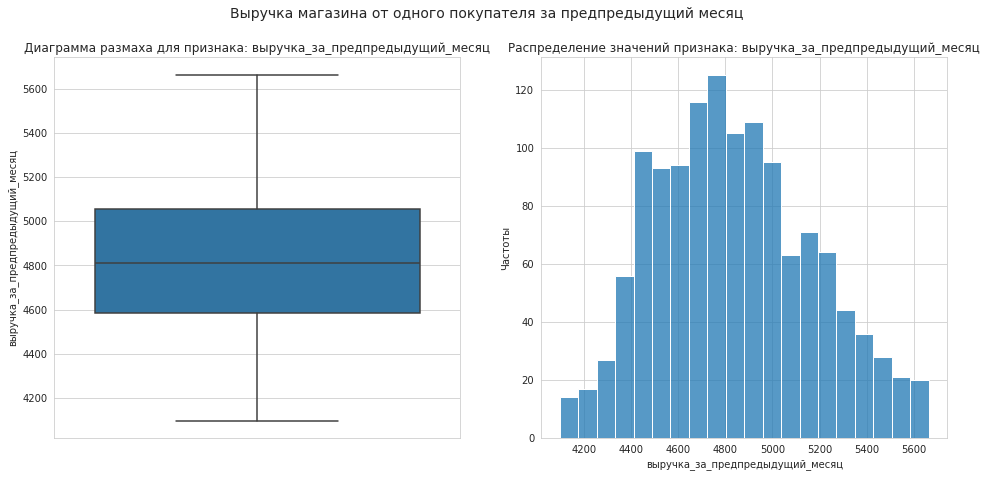

In [48]:
# построим графики для признака 'выручка_за_предпредыдущий_месяц'
num_feature_plots(data=market_money_by_period, feature='выручка_за_предпредыдущий_месяц', bins=20,
                  name = 'Выручка магазина от одного покупателя за предпредыдущий месяц')

Среди значений признака нет выбросов. Распределение близко к нормальному, медианное значение приходится на 4812, среднее - 4836.

In [49]:
# создадим новый датафрейм для времени, проведенном на сайте
market_time_by_period = market_time.pivot_table(index='id', columns='период', values='минут').reset_index()
market_time_by_period.columns = ['id', 'минут_за_предыдущий_месяц', 'минут_за_текущий_месяц']
market_time_by_period.head()

,id,минут_за_предыдущий_месяц,минут_за_текущий_месяц
0,215349,12,10
1,215350,8,13
2,215351,11,13
3,215352,8,11
4,215353,10,10


In [50]:
# выводим описательную статистику по количественному признаку 'минут_за_текущий_месяц'
market_time_by_period['минут_за_текущий_месяц'].describe()

count    1297.000000
mean       13.211257
std         4.220222
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут_за_текущий_месяц, dtype: float64

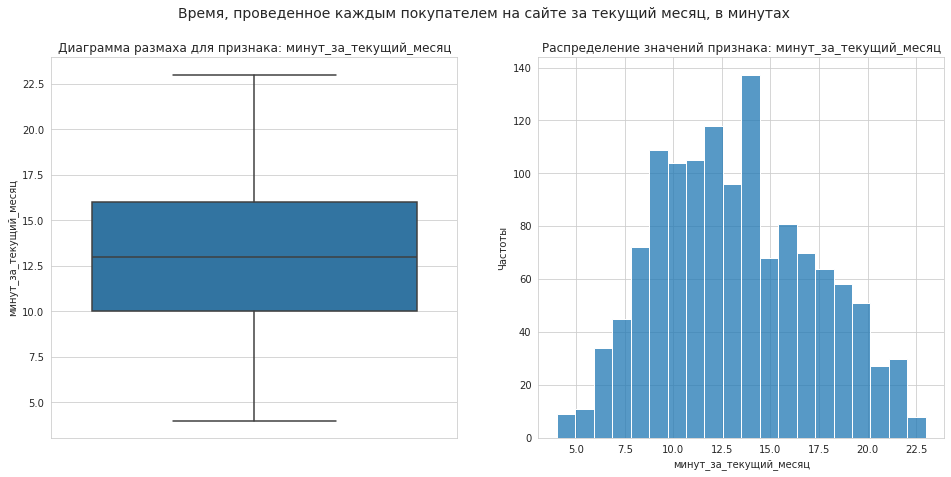

In [51]:
# построим графики для признака 'минут_за_текущий_месяц'
num_feature_plots(data=market_time_by_period, feature='минут_за_текущий_месяц', bins=20,
                  name = 'Время, проведенное каждым покупателем на сайте за текущий месяц, в минутах')

Выбросов по значениям времени, проведенном на сайте, нет. Распределение близко к нормальному, медианное значение равно 13 минутам.

In [52]:
# выводим описательную статистику по количественному признаку 'минут_за_предыдущий_месяц'
market_time_by_period['минут_за_предыдущий_месяц'].describe()

count    1297.000000
mean       13.469545
std         3.936323
min         5.000000
25%        11.000000
50%        13.000000
75%        17.000000
max        23.000000
Name: минут_за_предыдущий_месяц, dtype: float64

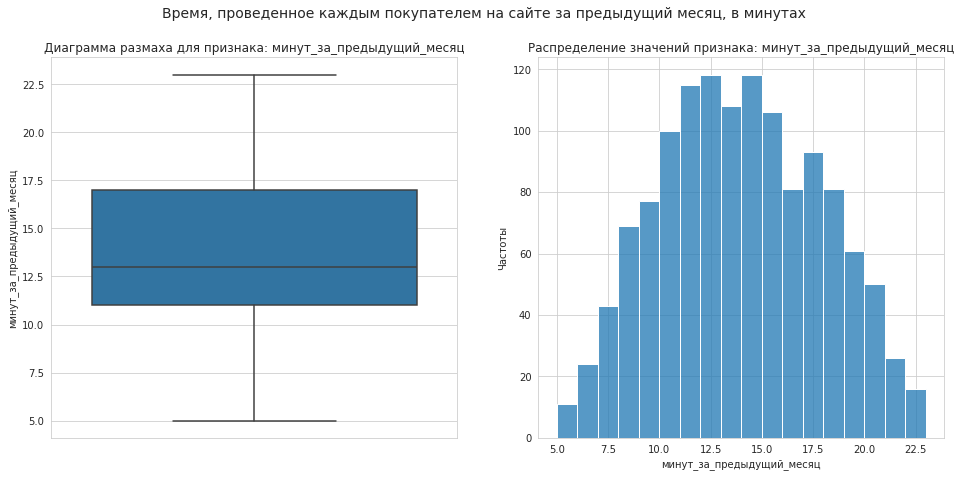

In [53]:
# построим графики для признака 'минут_за_предыдущий_месяц'
num_feature_plots(data=market_time_by_period, feature='минут_за_предыдущий_месяц', bins=18,
                  name = 'Время, проведенное каждым покупателем на сайте за предыдущий месяц, в минутах')

Выбросов по значениям времени, проведенном на сайте, нет. Распределение близко к нормальному, медианное значение равно 13 минутам.

In [54]:
# статистика по категориальному признаку 'покупательская_активность'
market_buyers['покупательская_активность'].value_counts()

Прежний уровень    802
Снизилась          495
Name: покупательская_активность, dtype: int64

In [55]:
# статистика по категориальному признаку 'тип_сервиса'
market_buyers['тип_сервиса'].value_counts()

стандарт    922
премиум     375
Name: тип_сервиса, dtype: int64

In [56]:
# статистика по категориальному признаку 'разрешить_сообщать'
market_buyers['разрешить_сообщать'].value_counts()

да     959
нет    338
Name: разрешить_сообщать, dtype: int64

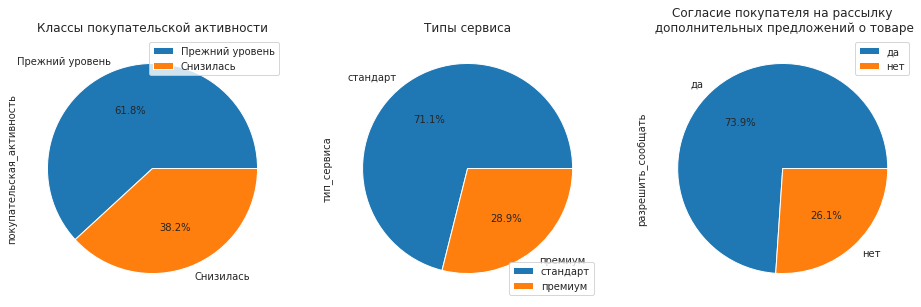

In [57]:
# с помощью subplots выводим круговые диаграммы для 3-х категориальных признаков 
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16,7))

# построим круговую диаграмму для категориального признака 'покупательская_активность'
market_buyers['покупательская_активность'].value_counts().plot(ax=axes[0], kind = 'pie', legend=True, autopct = '%1.1f%%')
axes[0].set_title('Классы покупательской активности')

# построим круговую диаграмму для категориального признака 'тип_сервиса'
market_buyers['тип_сервиса'].value_counts().plot(ax=axes[1], kind = 'pie', legend=True, autopct = '%1.1f%%')
axes[1].set_title('Типы сервиса')

# построим круговую диаграмму для категориального признака 'разрешить_сообщать'
market_buyers['разрешить_сообщать'].value_counts().plot(ax=axes[2], kind = 'pie', legend=True, autopct = '%1.1f%%')
axes[2].set_title('Согласие покупателя на рассылку\n дополнительных предложений о товаре')
plt.show()

На прежний уровень приходится почти 62%, на сниженный уровень - около 38%. Такое распределение классов целевого признака `покупательская активность` можно считать сбалансированным.

In [58]:
# статистика по категориальному признаку 'популярная_категория'
market_buyers['популярная_категория'].value_counts()

Товары для детей                        329
Домашний текстиль                       250
Косметика и аксессуары                  223
Техника для красоты и здоровья          183
Мелкая бытовая техника и электроника    174
Кухонная посуда                         138
Name: популярная_категория, dtype: int64

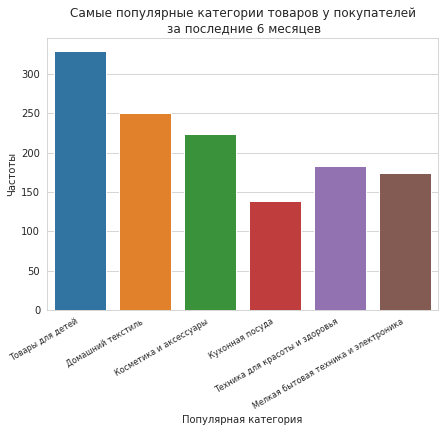

In [59]:
# построим столбчатую диаграмму для категориального признака 'популярная_категория'
plt.figure(figsize = (7, 5))
sns.countplot(data=market_buyers, x='популярная_категория')
plt.title('Самые популярные категории товаров у покупателей\n за последние 6 месяцев')
plt.xlabel('Популярная категория')
plt.xticks(fontsize=8, rotation=30, ha='right')
plt.ylabel('Частоты')
plt.show()

`Товары для для детей` - самая популярная категория. А `Кухонная посуда` - самая непопулярная. Покупателей с самой популярной категорией `Товары для для детей` почти в 2 раза больше, чем пользователей с самой популярной категорией `Кухонная посуда`.

**Выводы:**

Для решения задачи мы отобрали клиентов с покупательской активностью не менее трёх месяцев. Мы определили, что только у одного клиента есть нулевое значение выручки за один из 3-х месяцев, мы убрали такого клиента из всех датафреймов. Одно аномально высокое значение выручки, которую приносит один из пользователей за текущий месяц, мы заменили на среднее значение выручки по тому же периоду. Наличие аномальных выбросов осложняет поиск и точность прогнозной модели. 

Признаки `длительность`, `число сбоев`, `прибыль`, `выручка_за_текущий_месяц`, `выручка_за_предпредыдущий_месяц`, `минут_за_предыдущий_месяц`, `минут_за_текущий_месяц` имеют распределение, близкое к нормальному. Остальные количественные признаки показывают распределение, отличное от нормального. Кроме того по части признаков наблюдаются незначительные выбросы, которые нужно учитывать при построении оптимальной прогнозной модели. Значения целевого признака `покупательская активность` имеют незначительный различия в распределении классов, можно сказать, что классы сбалансированы, а следовательно в задаче нет проблемы дисбаланса классов. 




## Объединение таблиц

In [60]:
# объединим 3 датафрейма с помощью метода merge(), в качестве ключа используем значения 'id'
full_market = pd.merge(market_buyers, market_money_by_period, on='id').merge(market_time_by_period, on='id')
full_market.head() # выведем первый строки нового датафрейма

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц,минут_за_предыдущий_месяц,минут_за_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10


**Выводы:**

Мы успешно объединили 3 датафрейма: датафрейм, который содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении; датафрейм с данными о выручке, которую получает магазин с покупателя за каждый месяц из 3-х; датафрейм с данными о времени (в минутах), которое покупатель провёл на сайте в течение текущего либо предыдущего месяца. Предварительно ещё на 3-м этапе мы преобразовали датафреймы с данными о выручке и о потрачененом на сайте времени, так чтобы данные за каждый из представленных периодов были выведены в отдельных столбцах (а не в одном по всем периодам, как в исходных данных). 


## Корреляционный анализ

In [61]:
# задаем непрерывные величины и считаем корреляционную матрицу между всеми признаками датафрейма full_market
interval_cols = ['маркет_актив_6_мес', 'длительность', 'акционные_покупки', 'выручка_за_предпредыдущий_месяц',\
                 'выручка_за_предыдущий_месяц', 'выручка_за_текущий_месяц']
phik_overview = phik_matrix(full_market.drop('id', axis=1), interval_cols = interval_cols)

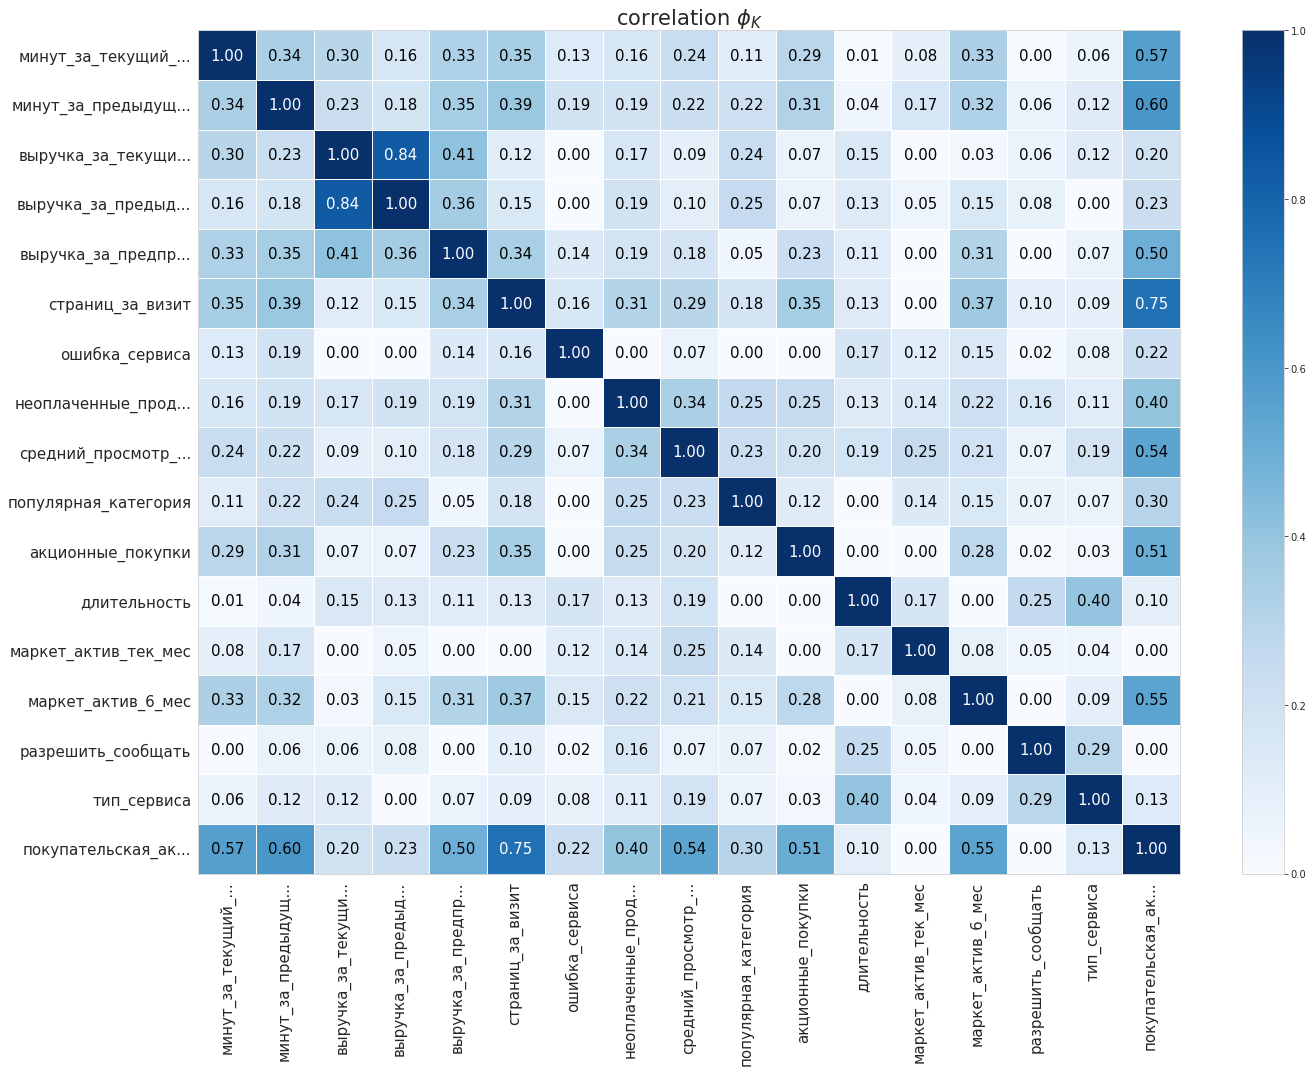

In [62]:
# визуализируем корреляции между всеми признаками датафрейма full_market
plot_correlation_matrix(phik_overview.values, x_labels=phik_overview.columns,\
                        y_labels=phik_overview.index, vmin=0, vmax=1, color_map='Blues',\
                        title='correlation $\phi_K$', fontsize_factor=1.5, figsize=(20, 15))


In [63]:
# добавляем константы для расчёта VIF, удаляем из данных для расчёта категориальные признаки
X = add_constant(full_market.drop(['id', 'покупательская_активность', 'тип_сервиса', 'популярная_категория', 'разрешить_сообщать'], axis=1))

# расчет VIF для каждого предиктора
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['vif_coef'] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data.round(2) # выводим коэффициенты по каждому количественному признаку

,feature,vif_coef
0,const,352.79
1,маркет_актив_6_мес,1.22
2,маркет_актив_тек_мес,1.04
3,длительность,1.10
4,акционные_покупки,1.19
5,средний_просмотр_категорий_за_визит,1.18
6,неоплаченные_продукты_штук_квартал,1.20
7,ошибка_сервиса,1.08
8,страниц_за_визит,1.42
9,выручка_за_предпредыдущий_месяц,1.61


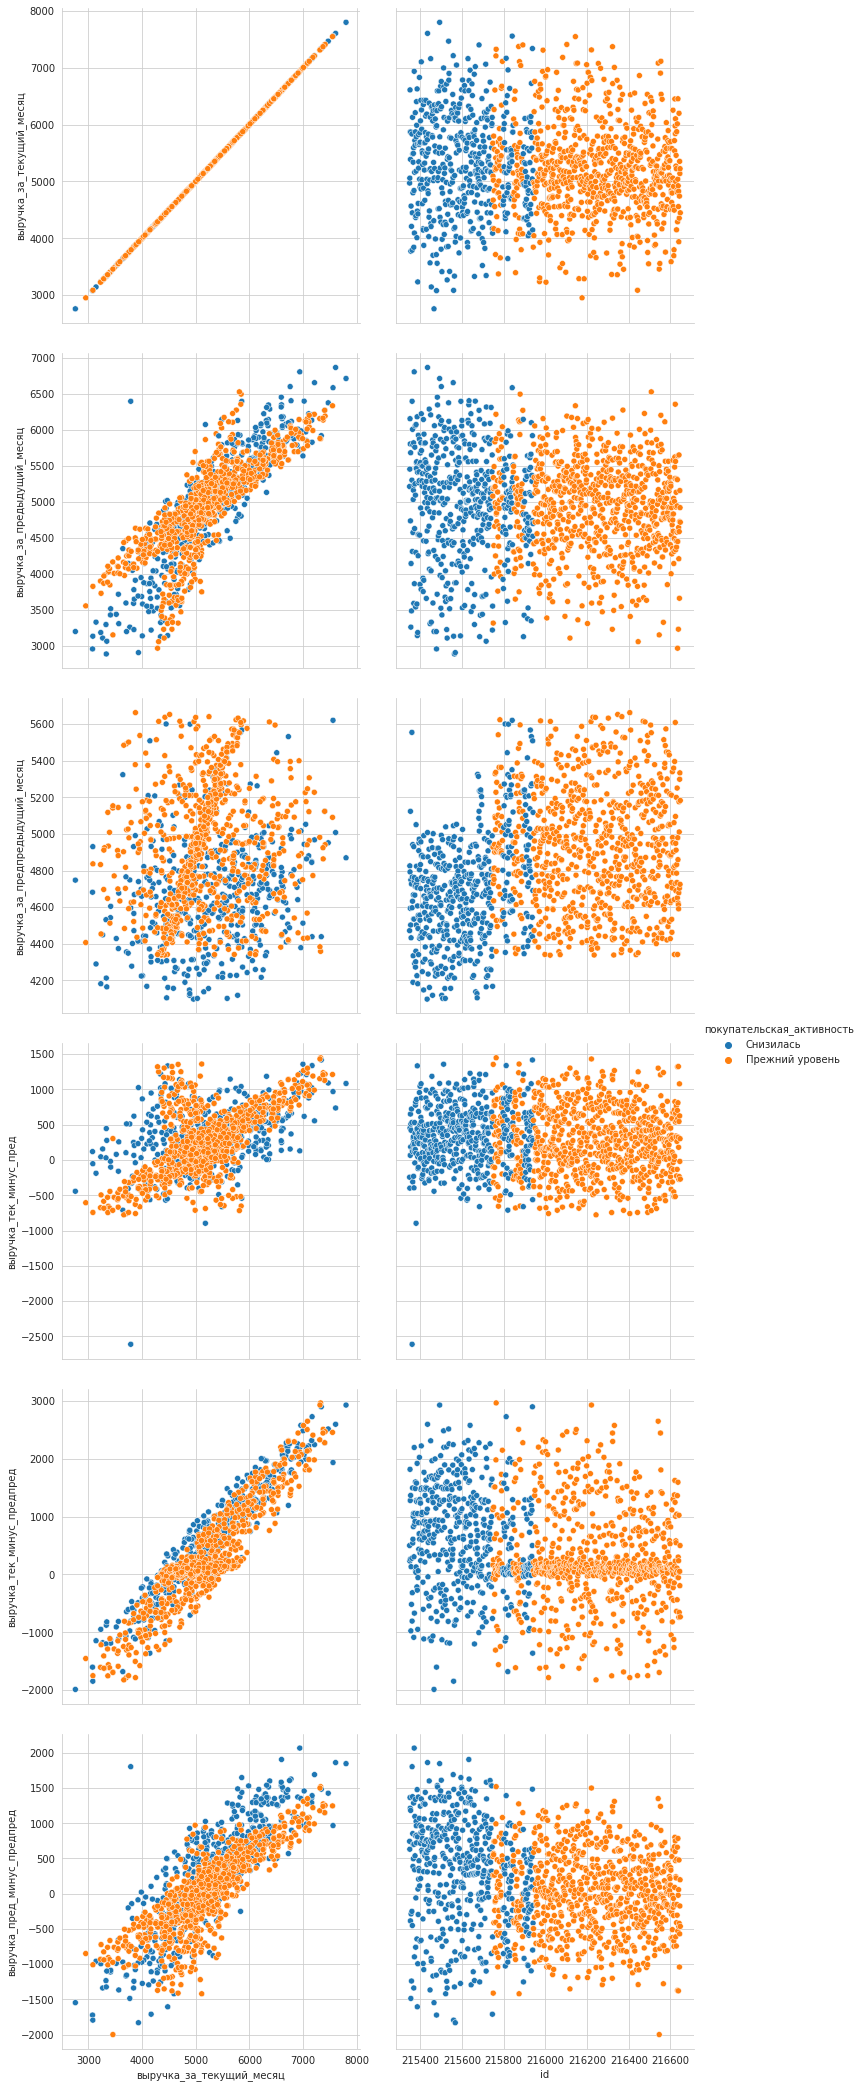

In [64]:
# посмотрим корреляцию между количесвтенными признаками на диаграммах раcсеяния в разрезе по целевому признаку
# создадим датафрейм для диаграмм рассеяния
# добавим новые признаки - разницыы между выручками за разные периоды
full_market_corr = full_market.drop(['тип_сервиса', 'разрешить_сообщать', 'маркет_актив_тек_мес', 'длительность'], axis=1)
full_market_corr['выручка_тек_минус_пред'] = full_market_corr['выручка_за_текущий_месяц']-full_market_corr['выручка_за_предыдущий_месяц']
full_market_corr['выручка_тек_минус_предпред'] = full_market_corr['выручка_за_текущий_месяц']-full_market_corr['выручка_за_предпредыдущий_месяц']
full_market_corr['выручка_пред_минус_предпред'] = full_market_corr['выручка_за_предыдущий_месяц']-full_market_corr['выручка_за_предпредыдущий_месяц']

# построим пары графиков рассеяния с помощью PairGrid для количественных признаков, указав разные признаки по строкам и столбцам
g = sns.PairGrid(
                 full_market_corr, x_vars =['выручка_за_текущий_месяц', 'id'],
                 y_vars=['выручка_за_текущий_месяц', 'выручка_за_предыдущий_месяц','выручка_за_предпредыдущий_месяц',
                        'выручка_тек_минус_пред', 'выручка_тек_минус_предпред', 'выручка_пред_минус_предпред'], 
                 height=5, layout_pad=2, hue='покупательская_активность'
                )
g.map(sns.scatterplot)
g.add_legend()

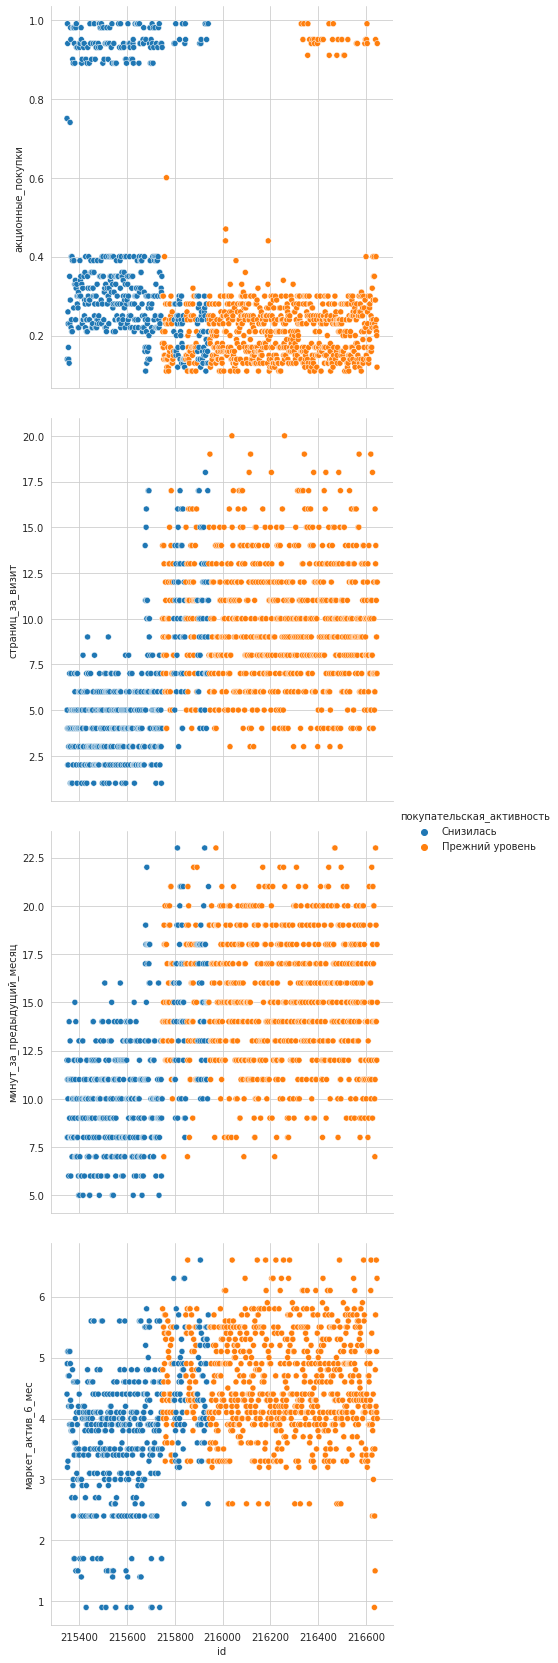

In [65]:
# построим пары графиков рассеяния с помощью PairGrid для 'id' и других признаков с заметной корреляцией с целевым признаком
g_2 = sns.PairGrid(
                 full_market_corr, x_vars =['id'],
                 y_vars=['акционные_покупки', 'страниц_за_визит', 'минут_за_предыдущий_месяц',
                         'маркет_актив_6_мес'], 
                 height=6, layout_pad=2, hue='покупательская_активность'
                )
g_2.map(sns.scatterplot)
g_2.add_legend()

**Выводы:**

Мы посчитали корреляцию между всеми признаками с помощью коэффициента корреляции Фи, который позволяет считать коэффициент корреляции как для количественных, так и для категорийных переменных. Мы вывели матрицу корреляции для всех признаков из таблицы для моделирования кроме 'id'. Столбец со значениями 'id' следует исключить для моделирования. Между оставшимися признаками наиболее высокая корелляционная связь наблюдается между признками `выручка_за_текущий_месяц` и `выручка_за_предыдущий_месяц` - значение коэффициента 0.84. Однако, коэффициент меньше 0.9, что можно трактовать как отсустутствие мультиколлинеарности. Между остальными признаками не наблюдается таких высоких коэффициентов корреляции. Целевой признак `покупательская_активность` имеет сильную корреляционную связь с кол-вом просмотренных страниц за визит (`страниц_за_визит`) и заметную корреляционную связь с признаками времени, проведенном на сайте (`минут_за_текущий_период`, `минут_за_предыдущий_период`), `маркет_актив_6_мес`, `акционные_покупки`, `средний_просмотр_категорий_за_визит`, `выручка_за_предпредыдущий_месяц`. Кроме того, мы посчитали коэффициент инфляции дисперсии (VIF) для всех количетенных признаков. Мы получили наиболее высокий коэффициент для признака `выручка_за_предыдущий_месяц`: 4.24. Значения выше 4 могут говорить о наличии существенной мультуколлинеарности, поэтому признак `выручка_за_предыдущий_месяц` можно исключить из моделирования.

Мы также вывели диаграммы рассеяния для количественных признаков, имеющих заметную или высокую корреляцию с целевым признаком. Точки на диаграммах мы сгруппировали в разрезе по значениям целевого признака. Для нас важно было посмотреть на графиках взаимосвязи между выручкой за разные периоды. Мы видим, что между значениями выручки за текущий месяц (признак `выручка_за_текущий_месяц`) и выручки за предыдущий месяц (признак `выручка_за_предыдущий_месяц`) прослеживаются линейные зависимости. При этом зависимость более явно проявляется в отношении покупателей, чья активность снизилась. Все значения текущей выручки в зависимости от значений выручки за прошлый месяц выстраиваются в ряд, приближаясь к одной условной линии. Это восходящая линия, с увеличением выручки за прошлый месяц растут и  значения выручки в текущем месяце. Для покупателей с прежним уровнем активности наблюдается два условных тренда - часть точек выстроена вокруг линии под большим углом (т.е. при росте значений выручки за прошлый месяц выручка в текущем месяце растет не так быстро), а часть выстроена вокруг линии под углом менее 45 градусов, т.е. по мере роста выручки за прошлый месяц, выручка за текущий месяц растет медленнее. Схожим образом проявляется зависимость между значениями выручки в текущем месяце и значениями разницы между выручками за предыдущий и предпредыдущий период: для обоих категорий покупателей проявляются явные тренды, для покупателей со снижающимся уровнем активности линия тренда имеет больший угол, чем для покупателей с прежним уровнем активности. Также разброс значений выручки за текущий месяц уменьшается, когда разница между выручками (в предыдущем и предпредыдущем месяце) становится выше 0, т.е. когда есть тренд к росту выручки. Получается, что при показанной на графиках линейной зависимости мы можем спрогнозировать значения выручки в текущем месяце, зная значения выручки за два предыдущих месяца. Мы принимаем решение убрать признак `выручка_за_предыдущий_месяц` из прогнозной модели.

Значения признака `выручка_за_предпредыдущий_месяц` для покупателей со снижающимся уровнем активности чаще занимает более низкие значения по сравнению с категорией покупателей с прежним уровнем покупательской активности. В предыдущем и текущем месяцах уже нет заметной разницы в значениях выручки покупателей по целевому признаку. Для покупателей со снижающимся уровнем покупательской активности значения по признакам `страниц_за_визит`, `минут_за_предыдущий_месяц`, `маркет_актив_6_мес` чаще приобретают более низкие значения и реже высокие значения по сравнению с категорией покупателей с прежним уровнем покупательской активности. Обе категории покупателей по целевому признаку заметно отличаются между собой по значениям признака `'акционные_покупки'`: у покупателей со снижающимся уровнем активности сравнительно редко бывают значения ниже 0.2, тогда как у покупателей с прежним уровнем активности такие значения встречаются почти в половине случаев. Также мы видим очень заметную группу покупателей со снижающейся активностью с долей акционных покупок выше 0.8, хотя такие покупатели есть и во второй группе, их гораздо меньше.

## Использование пайплайнов

In [66]:
# задаем выборочные и целевую переменную
X = full_market.drop(['покупательская_активность', 'выручка_за_предыдущий_месяц', 'id'], axis=1)
y = full_market['покупательская_активность']

# разделяем данные на тренировочную и тестовую выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = TEST_SIZE,
                                                    random_state = RANDOM_STATE,
                                                    stratify = y)

# кодируем целевой признак
label_encoder = LabelEncoder()
y_train_le = label_encoder.fit(y_train)
label_encoder.classes_ = np.array(['Прежний уровень', 'Снизилась'])
y_train_le = label_encoder.transform(y_train)
y_test_le = label_encoder.transform(y_test)

In [67]:
# выделяем категориальные переменные для двух типов кодирования и количественные для масштабирования 
ohe_columns = ['тип_сервиса', 'разрешить_сообщать', 'популярная_категория']

num_columns = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит',\
               'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_за_предпредыдущий_месяц',\
               'выручка_за_текущий_месяц', 'минут_за_предыдущий_месяц', 'минут_за_текущий_месяц']

In [68]:
# создаем пайплайн для кодирования категориальных признаков
ohe_pipe = Pipeline([('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
                     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False))])


In [69]:
# создаём общий пайплайн для подготовки данных, включаем в него тип масштабирования и количественные переменные для масштабирования
data_preprocessor = ColumnTransformer([('ohe', ohe_pipe, ohe_columns),
                                       ('num', StandardScaler(), num_columns)],
                                        remainder='passthrough')

# создаём итоговый пайплайн
final_pipe = Pipeline([('preprocessor', data_preprocessor),
                       ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))])


In [70]:
# задаем словари гиперпараметров для четырёх моделей
              # для модели LogisticRegression()
param_grid = [{'models': [LogisticRegression(random_state=RANDOM_STATE, penalty='l1', solver='liblinear')],
               'models__C': range(1, 6),
               'preprocessor__num': [StandardScaler(), MinMaxScaler()]},
              # для модели KNeighborsClassifier()
              {'models': [KNeighborsClassifier()],
               'models__n_neighbors': range(3, 11),
               'models__metric': ['euclidean', 'cityblock'],
               'preprocessor__num': [StandardScaler(), MinMaxScaler()]},
              # для модели DecisionTreeClassifier()              
              {'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
               'models__max_depth': range(2, 6),
               'preprocessor__num': [StandardScaler(), MinMaxScaler()]},
              # для модели SVC()  
              {'models': [SVC(random_state=RANDOM_STATE, probability=True)],
               'models__kernel': ['rbf','sigmoid', 'poly'],
               'models__C': range(1, 6),
               'preprocessor__num': [StandardScaler(), MinMaxScaler()]}]

# находим лучшую модель на данных тренировочной выборки
grid = GridSearchCV(final_pipe, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train_le)
# Выводим параметры лучшей модели
print('Лучшая модель и её параметры:\n\n', grid.best_params_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Лучшая модель и её параметры:

 {'models': SVC(probability=True, random_state=42), 'models__C': 2, 'models__kernel': 'poly', 'preprocessor__num': StandardScaler()}


In [71]:
# считаем и выводим для лучшей модели метрику точности roc_auc
print('Значение метрики ROC_AUC для лучшей модели:', round(grid.best_score_, 3))
# по лучшей модели делаем прогноз на тестовой выборке
y_pred_proba = grid.predict_proba(X_test)[:,1]
# считаем и выводим для лучшей модели метрику roc_auc на тестовой выборке
roc_auc = roc_auc_score(y_test_le, y_pred_proba)
print('Значение метрики ROC_AUC для лучшей модели на тестовой выборке:', round(roc_auc, 3))

Значение метрики ROC_AUC для лучшей модели: 0.916
Значение метрики ROC_AUC для лучшей модели на тестовой выборке: 0.919


**Выводы:**

Мы провели поиск оптимальной модели, применив пайплайны. Предварительно мы кодировали целевой признак с помощью кодировщика LabelEncoder(), так что значения признака "Прежний уровень" преобразовались в 0, а значения "Снизилась" - в 1. Затем мы отобрали признаки для кодирования и масштабирования и создали пайплайн для кодирования признаков методами OneHotEncoder(). На следующем шаге мы создали общий пайплайн для подготовки данных, включив в него пайплайн для кодирования и скалер для масштабирования данных методом StandardScaler(). После этого мы создали итоговый пайплайн для решения задачи. 

Затем мы задали словари с гиперпараметрами для четырех моделей: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC(). Для каждой модели мы задали гипермапарметры. Для модели LogisticRegression() мы задали l1-регуляризацию, которая сокращает веса незначимых признаков вплоть до нуля, и подбор значения параметра силы регуляризации C - значения от 1 до 5 включительно. Для модели KNeighborsClassifier() мы задали подбор оптимального кол-ва ближайших соседей для классификации - от 3 до 10 включительно, а также на выбор две опции рассчёта расстояния между объектами - 'euclidean' и 'cityblock'. Для модели DecisionTreeClassifier() мы задали подбор оптимальной глубины дерева - значения от 2 до 5 включительно. Для модели SVC мы задали подбор оптимального типа ядра для использования в алгоритме модели - 'rbf', 'sigmoid', 'poly', а также коэффициент силы регуляризации C - значения от 1 до 5 включительно. Кроме того, для всех четырех моделей мы установили подбор оптимального метода масштабирования количественных признаков - StandardScaler() и MinMaxScaler().

В заключении мы запустили оптимизацию гиперпараметров с помощью селектора GridSearchCV, в который включили заданный словарь гиперпараметров, тип кросс-валидации (задали значение 5) и метрику для оценки качества обученных моделей. Мы выбрали для оценки качества моделей метрику `'roc-auc'`. Эта метрика отлично подходит для решения задачи бинарной классификации, кроме того она учитывает работу модели при всех возможных значениях порогов для классификации и поэтому не зависит от одного конкретного.

Таким образом, мы использовать один общий пайплайн для всех моделей и инструмент подбора гиперпараметров. 

После применения поиска лучшей модели мы обучили её на тренировочной выборке и затем вывели ёё параметры. В результате мы получили, что лучшая модель для решения задачи классификации пользователей по покупательской активности - это модель опорных векторов SVC(probability=True, random_state=42) с оптимальными пармаетрами C=2, kernel='poly' и масштабированием StandardScaler(). Значение метрики ROC_AUC для лучшей модели, полученной на кросс-валидационной выборке - 0.916, на тестовой выборке - 0.919.

## Анализ важности признаков 

In [72]:
# обратимся к пайплайну подготовки данных и вытащим из него тренировочные и тестовые выборки после кодирования и масштабирования
X_train_new = pd.DataFrame(data_preprocessor.fit_transform(X_train),
                           columns=data_preprocessor.get_feature_names_out())

X_test_new = pd.DataFrame(data_preprocessor.transform(X_test),
                          columns=data_preprocessor.get_feature_names_out())

In [73]:
# зададим модель с параметрами, которая была выбрана лучшей с найденными оптимальными параметрами
best_model = SVC(random_state=RANDOM_STATE, kernel='poly', probability=True, C=2)
# обучим модель
best_model.fit(X_train_new, y_train_le)

SVC(C=2, kernel='poly', probability=True, random_state=42)

PermutationExplainer explainer: 326it [02:02,  2.52it/s]                         


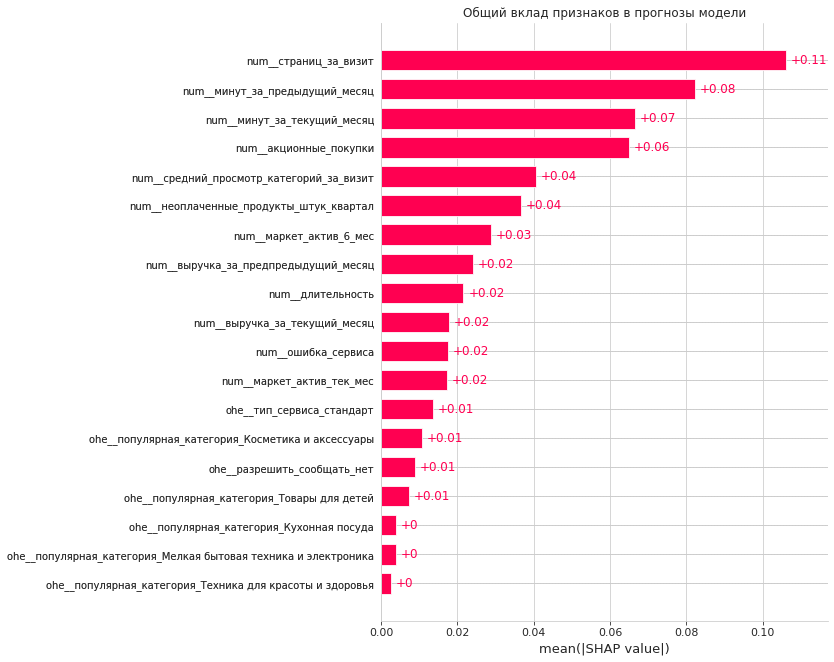

In [74]:
# передадим в эксплейнер обученную лучшую модель и срез по тренировочной выборке
# применим метод SHAP на тестовой выборке
explainer = shap.Explainer(best_model.predict,
                           X_train_new)
shap_values = explainer(X_test_new)

# визуализируем общий вклад признаков в прогнозы модели
shap.plots.bar(shap_values, max_display=19, show=False)
plt.yticks(fontsize=10)
plt.title('Общий вклад признаков в прогнозы модели')
plt.show()

Text(0.5, 1.0, 'Вклад признаков в предсказания модели')

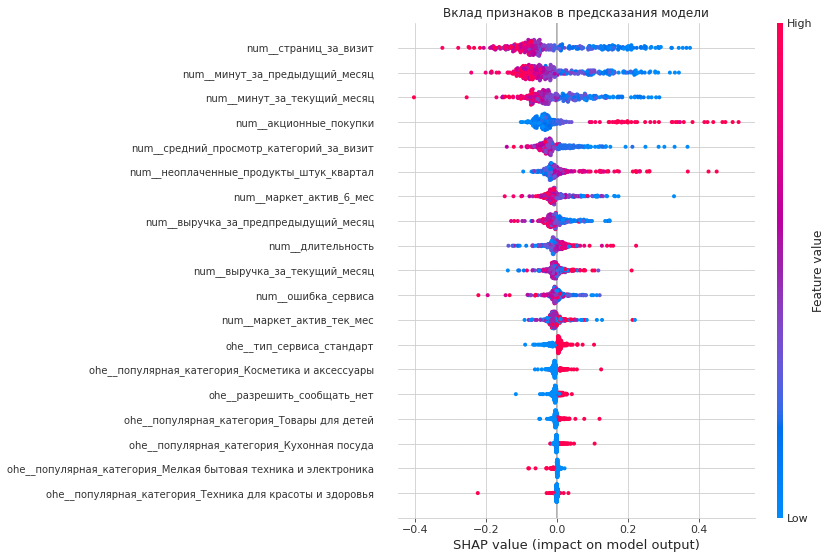

In [75]:
# визуализируем вклад признаков в каждое предсказание модели
shap.plots.beeswarm(shap_values, max_display=19, show=False)
plt.yticks(fontsize=10)
plt.title('Вклад признаков в предсказания модели')

**Выводы:**

С помощью метода SHAP мы определили значимость признаков для лучшей модели, выбранной на предыдущем шаге. В результате для каждого признака, используемого моделью, было посчитано значение Шепли. На первом графике мы визуализировали общий вклад признаков в прогнозы модели. На графике изображены средние SHAP-значения признака по всем наблюдениям (значения Шепли для каждого наблюдения взяты по модулю). Наименее значимыми для выбранной лучшей модели являются признаки `популярная_категория` (мы кодировали признак с помощью OHE, поэтому их несколько). SHAP-значения равны 0 для значений признака "Техника для красоты и здоровья", "Кухонная посуда" и "Мелковая бытовая техника и электроника", а для остальных 3-х значений равно +0.01. Также невысокую значимость имеют признаки `тип_сервиса` и `разрешить_сообщать`, их вклад на значение целевого признака измеряется средним SHAP-значением +0.01.

На основе того же графика общего вклада признаков мы можем определить признаки, которые сильнее всего влияют на целевой признак - `страниц_за_визит`, `минут_за_предыдущий_месяц`, `акционные_покупки`, `минут_за_текущий_месяц`. Для признака `страниц_за_визит` среднее SHAP-значение составляет +0.11, для признака `минут_за_предыдущий_месяц` — +0.08, для признака `минут_за_текущий_месяц` — +0.06, для признака `акционные_покупки` — +0.07. 

При необходимиости дальнейшего улучшения модели, можно убрать из модели наименее значимые признаки, а также попробовать применить полиномизацию признаков. Кроме того наименее значимые признаки не следует использовать на следующем шаге сегментации покупателей. Также при принятии бизнес-решений больше внимания следует уделить указанным выше четырем наиболее значимым признакам, тогда как наименее значимыми признаками можно пренебречь при разработке персонализированных предложений по клиентам для увеличения их покупательской активности.

На втором графике мы визуализировали вклад каждого из признаков в каждое предсказание модели. График позволяет интерпретировать прежде всего, как высокие значения признака влияет на целевой признак. Так, например, высокие значения признаков `страниц_за_визит`, `минут_за_предыдущий_месяц`, `минут_за_текущий_месяц`, `выручка_за_предпредыдущий_месяц`, `средний_просмотр_категорий_за_визит` склоняют целевой признак `покупательская_активность` к классу 0 — покупательская активность осталась на прежнем уровне. А, например, высокие значения признаков `акционные_покупки`, `неоплаченные_продукты_штук_квартал`, `длительность` склоняют целевой признак к классу 1 — покупательская активность снизилась. Очевидно, высокие доля акционных покупок и кол-во неоплаченных продуктов может сигнализировать о снижении активности покупателя, тогда как высокие значения кол-ва просмотренных страниц за визит и времени, проведенном на сайте, может косвенно говорить о высокой покупательской активности. Однако, все же следует смотреть на все признаки (за исключением наименее значимых признаков) и их значения в совокупности.

## Сегментация покупателей 

In [76]:
# добавляем данные по прибыли к датафрейму, полученному на шаге 4
market_segmentation = full_market.merge(profit, on='id')

In [77]:
# удаляем незначимые признаки и признак с кодированными значениями целевого признака
market_segmentation = market_segmentation.drop(['тип_сервиса', 'разрешить_сообщать'], axis=1)

In [78]:
# выводим первый строки датафрейма
market_segmentation.head()

,id,покупательская_активность,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц,минут_за_предыдущий_месяц,минут_за_текущий_месяц,прибыль
0,215349,Снизилась,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,4.16
1,215350,Снизилась,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,3.13
2,215351,Снизилась,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,4.87
3,215352,Снизилась,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,4.21
4,215353,Снизилась,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,3.95


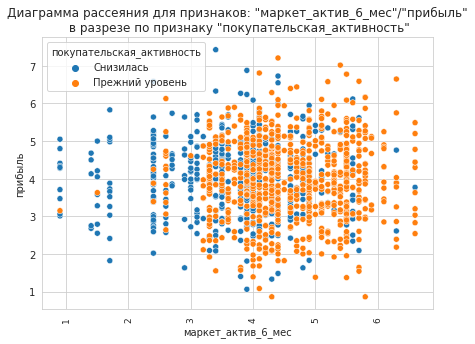

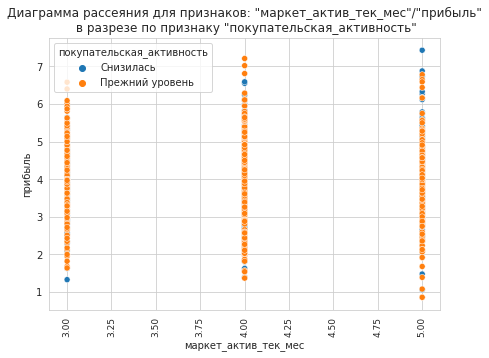

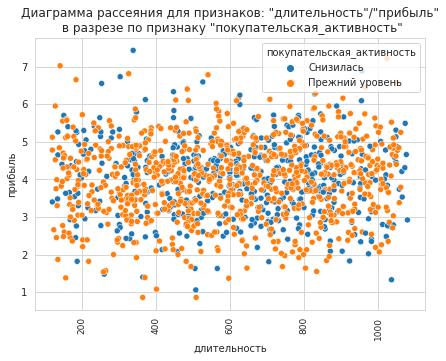

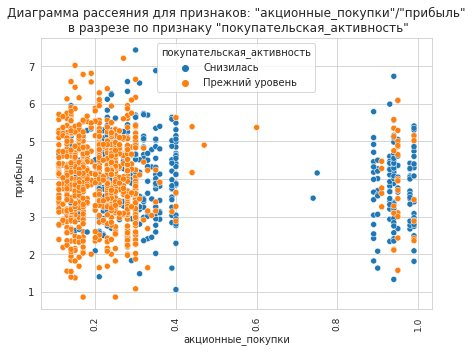

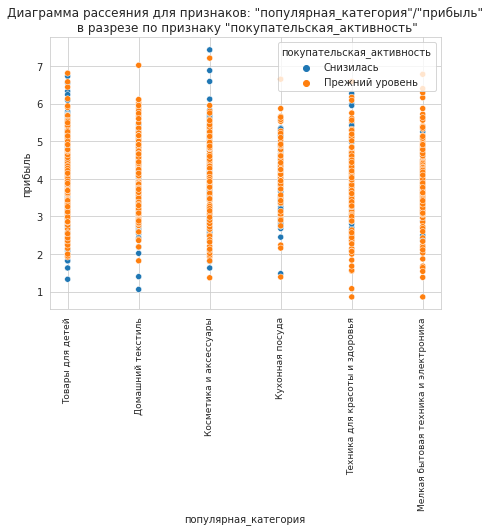

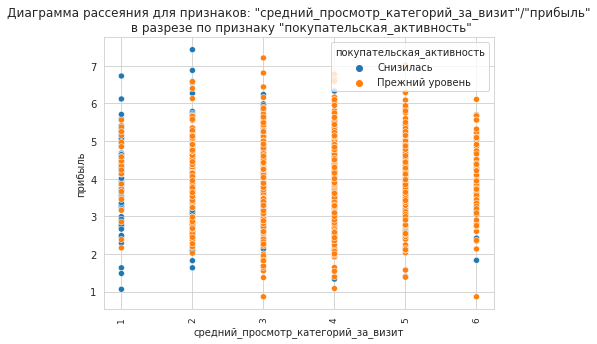

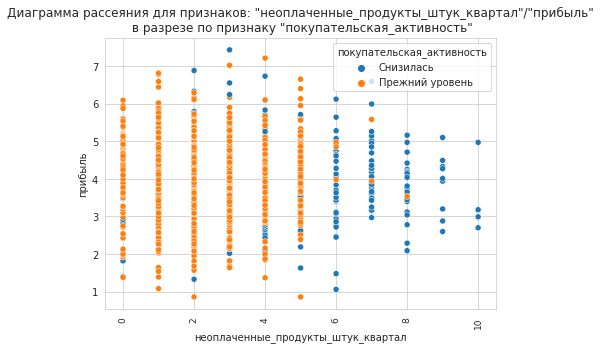

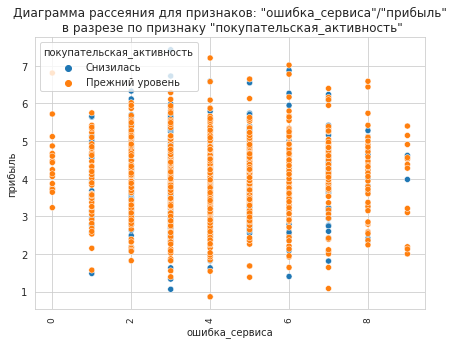

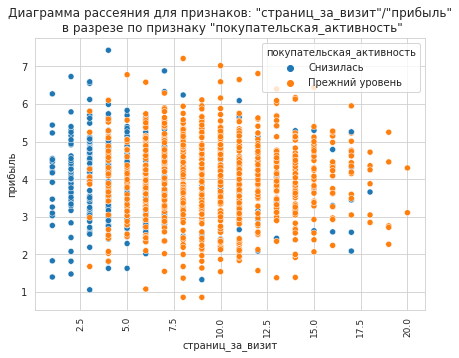

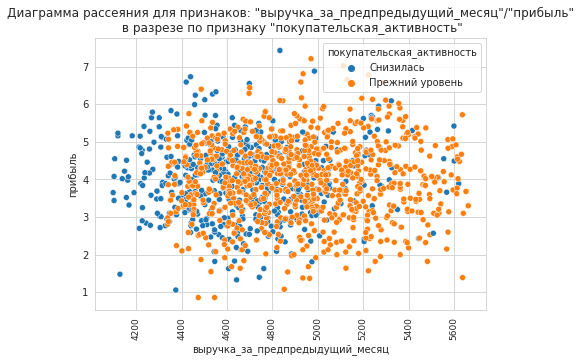

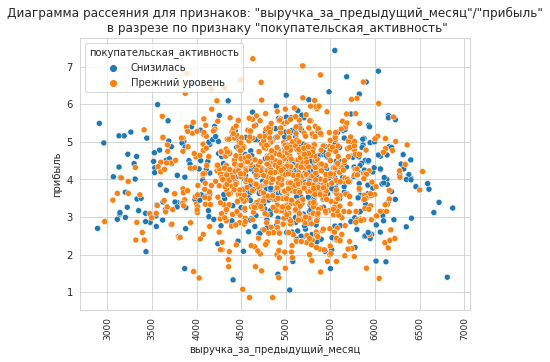

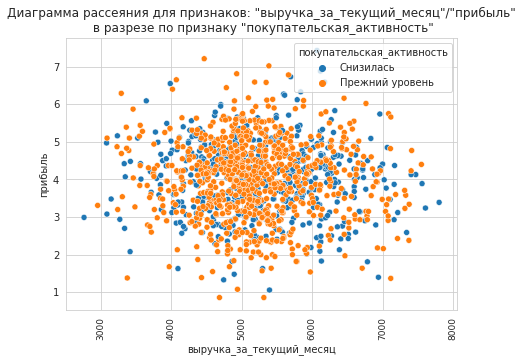

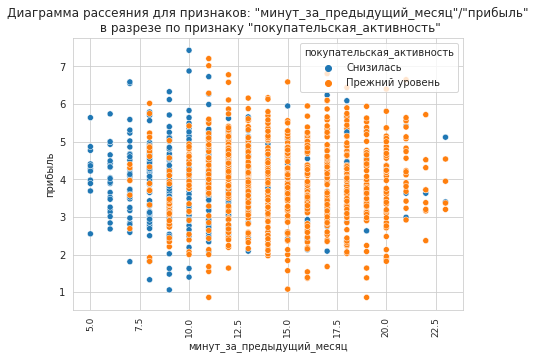

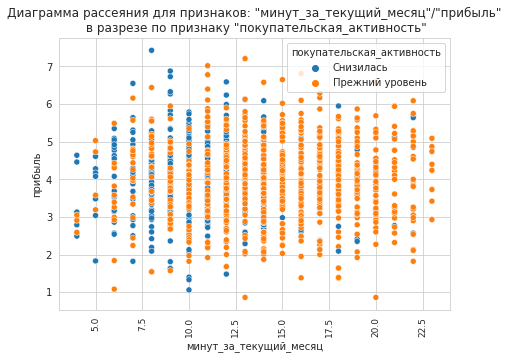

In [79]:
# задаём цикл для перебора признаков и построения диаграмм рассеяния для выбранного признака и прибыли
# в качестве группирующего признака выбираем покупательскую активность
for i in market_segmentation.columns:
    if (i!='покупательская_активность') & (i!='прибыль') & (i!='id'):
        plt.figure(figsize = (7, 5))
        sns.scatterplot(data=market_segmentation, x=i, y='прибыль', hue='покупательская_активность')
        plt.title(f'Диаграмма рассеяния для признаков: "{i}"/"прибыль"\n в разрезе по признаку "покупательская_активность"')
        plt.xticks(rotation=90, fontsize=9)
        plt.show()

In [80]:
# сделаем сводную таблицу по выручке за 3 месяца (помесячно) в разрезе по популярным категориям
pop_cat = market_segmentation.pivot_table(values=['выручка_за_предпредыдущий_месяц', 'выручка_за_предыдущий_месяц', 'выручка_за_текущий_месяц'],
                                          columns='популярная_категория', aggfunc='sum').reset_index()
pop_cat.columns = ['месяц', 'Домашний текстиль', 'Косметика и аксессуары', 'Кухонная посуда', 
                   'Мелкая бытовая техника и электроника', 'Техника для красоты и здоровья', 'Товары для детей']
pop_cat

,месяц,Домашний текстиль,Косметика и аксессуары,Кухонная посуда,Мелкая бытовая техника и электроника,Техника для красоты и здоровья,Товары для детей
0,выручка_за_предпредыдущий_месяц,1211765.0,1075455.0,665251.0,850017.0,885501.0,1584780.0
1,выручка_за_предыдущий_месяц,1273835.5,1137351.0,718523.0,874921.0,854352.0,1559014.0
2,выручка_за_текущий_месяц,1341309.4,1199034.7,766812.8,920019.3,912413.0,1654163.6


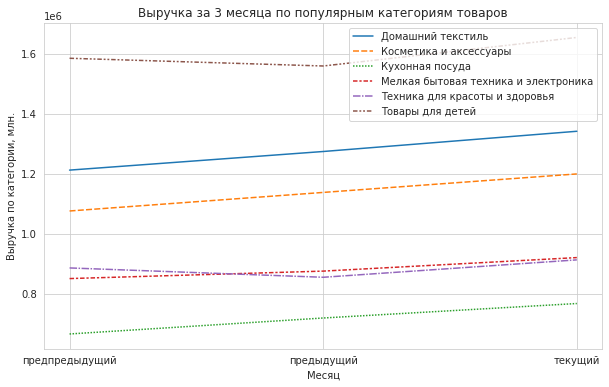

In [81]:
# отразим на графике помесячную выручку за 3 месяца по каждой популярной категории
x_ticks_labels = ['предпредыдущий', 'предыдущий', 'текущий']
x_ticks_posistion = range(0,3)
plt.figure(figsize=(10, 6))
sns.lineplot(data=pop_cat)
plt.title('Выручка за 3 месяца по популярным категориям товаров')
plt.xlabel('Месяц')
plt.ylabel('Выручка по категории, млн.')
plt.xticks(x_ticks_posistion, x_ticks_labels)
plt.show()

**Выводы по сегментам:** 

Графики по значимым для лучшей модели признакам и прибыли, значения которых сгруппированны по двум категориям покупательской активности, помогают выявить несколько групп покупателей. 

По среднемесячному значению маркетинговых коммуникаций за последние 6 месяцев покупателей можно разделить на две группы: 1-я группа - меньше или равно 2.5; 2-я группа больше 2.5 коммуникаций. В первую группу преимущественно попадают пользователи, чья покупательская активность снизилась. Во второй группе представлены покупатели обоих категорий покупательской активности, при этом входит большинство покупателей, чья покупательская активность сохранилась на прежнем уровне.

По доли акционных покупок можно выделить три группы покупателей: 1-я группа - доля менее 0.35; 2-я группа - от 0.35 до 0.9 включительно; 3-я группа - доля более 0.9. Во вторую группу с долей акционных покупок от 0.35 до 0.9 преимущественно попадают покупатели, чья покупательская активность снизилась. В первую группу попадает большая часть покупателей с активностью на прежнем уровне. В третьей группе заметная доля у покупателей с прежней активностью, хотя большинсто составляют покупатели со снижением покупательской активности.

По общему числу неоплаченных товаров в корзине за последние 3 месяца пользователей можно разделить на два сегмента: 1-й - до 6; 2-й - больше или равно 6. В первом сегменте представлены обе категори покупателей, но большинство с прежним уровнем покупательской активности. Во второй сегмент преимущественно попали пользователи, чья покупательская активность снизилась.  

По среднему количеству страниц, просмотренных за один визит на сайт за последние 3 месяца, покупателей можно также разделить на 2 сегмента: менее или равно 2.5 и выше 2.5. В первый сегмент попадают исключительно покупатели со значениями покупательской активности "снизилась". Во вторую группу попали все покупатели с прежним уровнем покупательской активности и часть покупателей со снизившейся активностью.

По значению выручки за предпредыдущий месяц покупателей можно разделить на две группы: меньше или равно 4300 и более 4300. В первую группу преимущественно попадают пользователи, чья покупательская активность снизилась. Во второй представлены обе категории покупателей и за редким исключением попадают все покупатели с прежним уровнем покупательской активности.

По значению времени, проведённому на сайте за предыдущий месяц, пользователей можно разделить на две группы: менее 6 минут и от 6 минут. В первую группу преимущественно попадают пользователи, чья покупательская активность снизилась. Во вторую попали обе категори покупателей, включая большинство покупателей с прежним уровнем активности.

Графики показывают, что значение прибыли не имеет заметной связи с уровнем покупательской активности. Покупатели обоих категорий могут приносить как сравнительно высокую, так и сравнительно низкую прибыль магазину за выбранный период.

Дополнительно мы посмотрели графики по выручке помесячно в разрезе по признаку `популярная_категория`. Мы видим, что в целом темп роста выручки от продаж по каждой категории незначительный. При этом по категориям "Товары для детей" и "Техника для красоты и здоровья" выручка за предыдущий месяц снизились по сравнению с предпредыдущим месяцем, что конечно должно быть тревожно для компании. Особенное внимание нужно обратить на категорию "Продажи для детей", у этой категории как наиболее популярной самая большая доля продаж из всех шести категорий. Также мы видим что выручка по категории "Кухонная посуда" заметно меньше чем по другим категориям, а по сравнению с категорией "Товары для детей" продажи здесь более чем в 2 раза меньше. Компании стоит подумать, можно ли каким-то образом увеличить выручку по этой категории. 

Для дальнейшей подготовки персонализированных предложений для увеличения покупательской активности мы выбираем группу клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности.

In [82]:
# получим подготовленные данные из лучшей модели по полным данным объединенной таблицы по пользователям
X_full = pd.DataFrame(data_preprocessor.fit_transform(X),
                      columns=data_preprocessor.get_feature_names_out())

# получим прогнозные значения по всем пользователям 
y_full_pred = best_model.predict(X_full)
# получим предсказанные вероятности для класса 1
y_full_proba = best_model.predict_proba(X_full)[:,1]

In [83]:
# добавим предсказанные покупательскую активность и вероятность снижения покупательской активности к датафрейму для сегментации
market_segmentation['предсказание_покупательской_активности'] = y_full_pred
market_segmentation['вероятность_снижения'] = y_full_proba
market_segmentation.head()

,id,покупательская_активность,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц,минут_за_предыдущий_месяц,минут_за_текущий_месяц,прибыль,предсказание_покупательской_активности,вероятность_снижения
0,215349,Снизилась,4.4,4,819,0.75,Товары для детей,4,4,2,5,4472.0,5216.0,4971.6,12,10,4.16,1,0.828740
1,215350,Снизилась,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,4826.0,5457.5,5058.4,8,13,3.13,0,0.513078
2,215351,Снизилась,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,4.87,1,0.914798
3,215352,Снизилась,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,4.21,1,0.994872
4,215353,Снизилась,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,5124.0,4738.5,5388.5,10,10,3.95,1,0.667385


In [84]:
# отберем покупателей с долей акционных покупок выше 0.9 и предсказанной вероятностью снижения покупательской активности выше 0.7
segment_high_promo = market_segmentation[(market_segmentation['акционные_покупки'] > 0.9) & (market_segmentation['вероятность_снижения'] > 0.7)]
segment_high_promo.head()

,id,покупательская_активность,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц,минут_за_предыдущий_месяц,минут_за_текущий_месяц,прибыль,предсказание_покупательской_активности,вероятность_снижения
2,215351,Снизилась,3.2,5,896,0.99,Товары для детей,5,0,6,4,4793.0,6158.0,6610.4,11,13,4.87,1,0.914798
3,215352,Снизилась,5.1,3,1064,0.94,Товары для детей,3,2,3,2,4594.0,5807.5,5872.5,8,11,4.21,1,0.994872
13,215364,Снизилась,4.3,4,708,0.98,Домашний текстиль,3,3,3,3,4942.0,5795.5,5484.8,11,9,2.67,1,0.818812
14,215365,Снизилась,3.9,4,167,0.95,Техника для красоты и здоровья,6,4,2,5,4190.0,4577.0,4799.3,6,10,3.65,1,1.000000
23,215374,Снизилась,2.9,5,268,0.98,Домашний текстиль,6,3,2,2,4666.0,5762.5,5720.9,11,8,4.08,1,0.999998


In [85]:
# посмотрим значения покупательской активности для выбранного сегмента
segment_high_promo['покупательская_активность'].value_counts()

Снизилась          100
Прежний уровень      1
Name: покупательская_активность, dtype: int64

In [86]:
# выведем продажи по категориям за 3 месяца
segment_high_promo.pivot_table(index='популярная_категория', values=['выручка_за_предпредыдущий_месяц', 'выручка_за_предыдущий_месяц', 'выручка_за_текущий_месяц'], aggfunc='sum').reset_index()

,популярная_категория,выручка_за_предпредыдущий_месяц,выручка_за_предыдущий_месяц,выручка_за_текущий_месяц
0,Домашний текстиль,79409.0,85222.5,92265.9
1,Косметика и аксессуары,111844.0,126057.0,134202.8
2,Кухонная посуда,79299.0,93007.0,99352.3
3,Мелкая бытовая техника и электроника,24780.0,26427.0,27877.8
4,Техника для красоты и здоровья,46804.0,46679.5,49235.6
5,Товары для детей,129896.0,127744.0,133440.6


In [87]:
# посмотрим распределение покупателей по популярным категориям
segment_high_promo['популярная_категория'].value_counts()

Товары для детей                        28
Косметика и аксессуары                  24
Кухонная посуда                         17
Домашний текстиль                       17
Техника для красоты и здоровья          10
Мелкая бытовая техника и электроника     5
Name: популярная_категория, dtype: int64

In [88]:
# посмотрим распределение покупателей из сегмента по признаку 'средний_просмотр_категорий_за_визит'
segment_high_promo['средний_просмотр_категорий_за_визит'].describe()

count    101.000000
mean       2.683168
std        1.199422
min        1.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        6.000000
Name: средний_просмотр_категорий_за_визит, dtype: float64

In [89]:
# создадим выборку из покупателей с прежним уровнем активности того же размера что и сегментная группа
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'средний_просмотр_категорий_за_визит'
previous_level_buyers = market_segmentation[market_segmentation['покупательская_активность']=='Прежний уровень'
                                           ].sample(n=101, random_state=RANDOM_STATE)
previous_level_buyers['средний_просмотр_категорий_за_визит'].describe()

count    101.000000
mean       3.910891
std        1.241765
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        6.000000
Name: средний_просмотр_категорий_за_визит, dtype: float64

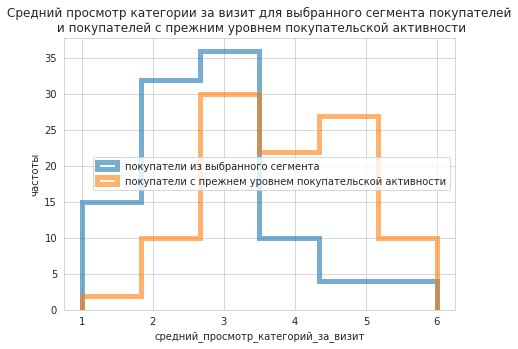

In [90]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['средний_просмотр_категорий_за_визит'].plot(kind='hist', histtype='step',
                                                                    grid=True, bins=6,
                                                                    linewidth=5, alpha = 0.6,
                                                                    figsize = (7, 5),
                                                                    label = 'покупатели из выбранного сегмента',
                                                                    legend=True)

previous_level_buyers['средний_просмотр_категорий_за_визит'].plot(kind='hist', histtype='step',
                                                                  grid=True, bins=6,
                                                                  linewidth=5, alpha = 0.6,
                                                                  figsize = (7, 5), ax=ax,
                                                                  label='покупатели с прежнем уровнем покупательской активности',
                                                                  legend=True)

plt.title('Средний просмотр категории за визит для выбранного сегмента покупателей\n и покупателей с прежним уровнем покупательской активности')
plt.xlabel('средний_просмотр_категорий_за_визит')
plt.ylabel('частоты')
plt.show()

In [91]:
# посмотрим распределение покупателей из сегмента по признаку 'минут_за_предыдущий_месяц'
segment_high_promo['минут_за_предыдущий_месяц'].describe()

count    101.000000
mean      10.237624
std        2.933082
min        5.000000
25%        8.000000
50%       10.000000
75%       12.000000
max       18.000000
Name: минут_за_предыдущий_месяц, dtype: float64

In [92]:
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'минут_за_предыдущий_месяц'
previous_level_buyers['минут_за_предыдущий_месяц'].describe()

count    101.000000
mean      14.603960
std        3.524427
min        8.000000
25%       12.000000
50%       14.000000
75%       18.000000
max       22.000000
Name: минут_за_предыдущий_месяц, dtype: float64

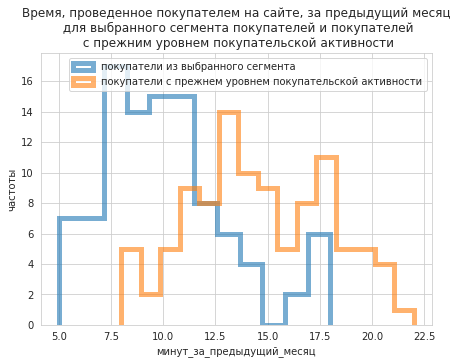

In [93]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['минут_за_предыдущий_месяц'].plot(kind='hist', histtype='step',
                                                          grid=True, bins=12, linewidth=5,
                                                          alpha = 0.6, figsize = (7, 5),
                                                          label = 'покупатели из выбранного сегмента',
                                                          legend=True)

previous_level_buyers['минут_за_предыдущий_месяц'].plot(kind='hist', histtype='step',
                                                        grid=True, bins=15, linewidth=5,
                                                        alpha = 0.6, figsize = (7, 5), ax=ax,
                                                        label='покупатели с прежнем уровнем покупательской активности',
                                                        legend=True)

plt.title('Время, проведенное покупателем на сайте, за предыдущий месяц\n для выбранного сегмента покупателей и покупателей\n с прежним уровнем покупательской активности')
plt.xlabel('минут_за_предыдущий_месяц')
plt.ylabel('частоты')
plt.show()

In [94]:
# посмотрим распределение покупателей из сегмента по признаку 'минут_за_текущий_месяц'
segment_high_promo['минут_за_текущий_месяц'].describe()

count    101.000000
mean      10.881188
std        2.919887
min        5.000000
25%        9.000000
50%       11.000000
75%       12.000000
max       19.000000
Name: минут_за_текущий_месяц, dtype: float64

In [95]:
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'минут_за_текущий_месяц'
previous_level_buyers['минут_за_текущий_месяц'].describe()

count    101.000000
mean      14.326733
std        4.188338
min        4.000000
25%       11.000000
50%       14.000000
75%       17.000000
max       22.000000
Name: минут_за_текущий_месяц, dtype: float64

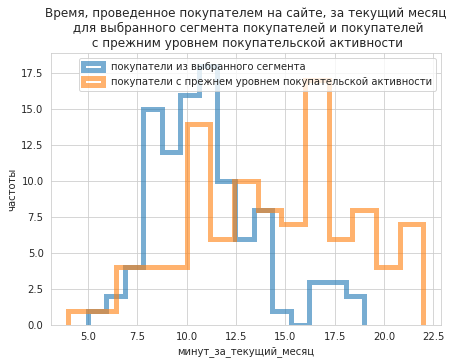

In [96]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['минут_за_текущий_месяц'].plot(kind='hist', histtype='step', grid=True,
                                                       bins=15, linewidth=5, alpha = 0.6,
                                                       figsize = (7, 5),
                                                       label = 'покупатели из выбранного сегмента',
                                                       legend=True)

previous_level_buyers['минут_за_текущий_месяц'].plot(kind='hist', histtype='step', grid=True,
                                                     bins=15, linewidth=5, alpha = 0.6,
                                                     figsize = (7, 5), ax=ax,
                                                     label='покупатели с прежнем уровнем покупательской активности',
                                                     legend=True)

plt.title('Время, проведенное покупателем на сайте, за текущий месяц\n для выбранного сегмента покупателей и покупателей\n с прежним уровнем покупательской активности')
plt.xlabel('минут_за_текущий_месяц')
plt.ylabel('частоты')
plt.show()

In [97]:
# посмотрим распределение покупателей из сегмента по признаку 'страниц_за_визит'
segment_high_promo['страниц_за_визит'].describe()

count    101.000000
mean       4.930693
std        2.486996
min        1.000000
25%        3.000000
50%        5.000000
75%        6.000000
max       13.000000
Name: страниц_за_визит, dtype: float64

In [98]:
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'страниц_за_визит'
previous_level_buyers['страниц_за_визит'].describe()

count    101.000000
mean      10.009901
std        3.401456
min        4.000000
25%        7.000000
50%       10.000000
75%       12.000000
max       18.000000
Name: страниц_за_визит, dtype: float64

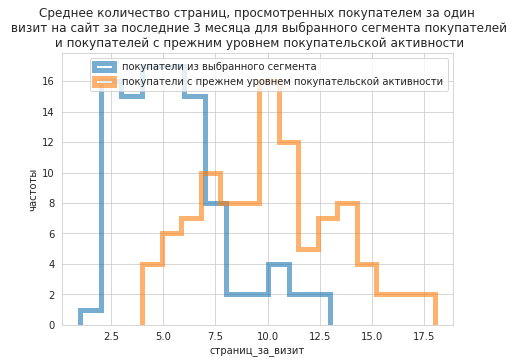

In [99]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['страниц_за_визит'].plot(kind='hist', histtype='step', grid=True,
                                                 bins=12, linewidth=5, alpha = 0.6,
                                                 figsize = (7, 5),
                                                 label = 'покупатели из выбранного сегмента',
                                                 legend=True)

previous_level_buyers['страниц_за_визит'].plot(kind='hist', histtype='step', grid=True,
                                               bins=15, linewidth=5, alpha = 0.6,
                                               figsize = (7, 5), ax=ax,
                                               label='покупатели с прежнем уровнем покупательской активности',
                                               legend=True)

plt.title('Среднее количество страниц, просмотренных покупателем за один\n визит на сайт за последние 3 месяца для выбранного сегмента покупателей\n и покупателей с прежним уровнем покупательской активности')
plt.xlabel('страниц_за_визит')
plt.ylabel('частоты')
plt.show()

In [100]:
# посмотрим распределение покупателей из сегмента по признаку 'маркет_актив_6_мес'
segment_high_promo['маркет_актив_6_мес'].describe()

count    101.000000
mean       3.709901
std        1.065130
min        0.900000
25%        3.100000
50%        3.900000
75%        4.400000
max        5.700000
Name: маркет_актив_6_мес, dtype: float64

In [101]:
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'маркет_актив_6_мес'
previous_level_buyers['маркет_актив_6_мес'].describe()

count    101.000000
mean       4.531683
std        0.821210
min        2.600000
25%        4.100000
50%        4.400000
75%        5.100000
max        6.600000
Name: маркет_актив_6_мес, dtype: float64

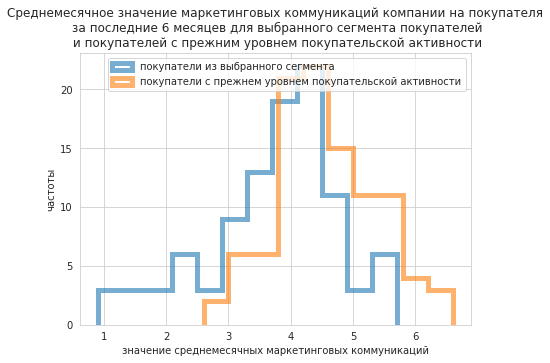

In [102]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['маркет_актив_6_мес'].plot(kind='hist', histtype='step', grid=True,
                                                   bins=12, linewidth=5, alpha = 0.6,
                                                   figsize = (7, 5),
                                                   label = 'покупатели из выбранного сегмента',
                                                   legend=True)

previous_level_buyers['маркет_актив_6_мес'].plot(kind='hist', histtype='step', grid=True,
                                                 bins=10, linewidth=5, alpha = 0.6,
                                                 figsize = (7, 5), ax=ax,
                                                 label='покупатели с прежнем уровнем покупательской активности', legend=True)

plt.title('Среднемесячное значение маркетинговых коммуникаций компании на покупателя\n за последние 6 месяцев для выбранного сегмента покупателей\n и покупателей с прежним уровнем покупательской активности')
plt.xlabel('значение среднемесячных маркетинговых коммуникаций')
plt.ylabel('частоты')
plt.show()

In [103]:
# посмотрим распределение покупателей из сегмента по признаку 'неоплаченные_продукты_штук_квартал'
segment_high_promo['неоплаченные_продукты_штук_квартал'].describe()

count    101.000000
mean       3.871287
std        2.536389
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       10.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64

In [104]:
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'неоплаченные_продукты_штук_квартал'
previous_level_buyers['неоплаченные_продукты_штук_квартал'].describe()

count    101.000000
mean       2.415842
std        1.444073
min        0.000000
25%        1.000000
50%        2.000000
75%        4.000000
max        5.000000
Name: неоплаченные_продукты_штук_квартал, dtype: float64

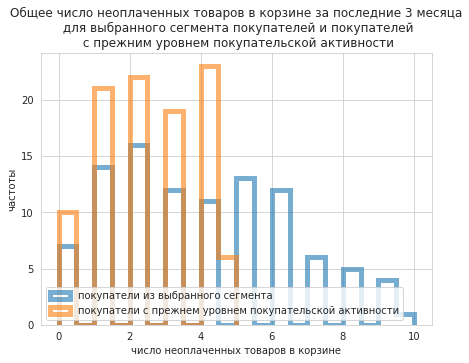

In [105]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['неоплаченные_продукты_штук_квартал'].plot(kind='hist', histtype='step', grid=True,
                                                                   bins=20, linewidth=5, alpha = 0.6,
                                                                   figsize = (7, 5),
                                                                   label = 'покупатели из выбранного сегмента',
                                                                   legend=True)

previous_level_buyers['неоплаченные_продукты_штук_квартал'].plot(kind='hist', histtype='step', grid=True,
                                                                 bins=10, linewidth=5, alpha = 0.6,
                                                                 figsize = (7, 5), ax=ax,
                                                                 label='покупатели с прежнем уровнем покупательской активности',
                                                                 legend=True)

plt.title('Общее число неоплаченных товаров в корзине за последние 3 месяца\n для выбранного сегмента покупателей и покупателей\n с прежним уровнем покупательской активности')
plt.xlabel('число неоплаченных товаров в корзине')
plt.ylabel('частоты')
plt.show()

In [106]:
# посмотрим распределение покупателей из сегмента по признаку 'прибыль'
segment_high_promo['прибыль'].describe()

count    101.000000
mean       3.862277
std        0.949642
min        1.330000
25%        3.180000
50%        4.000000
75%        4.420000
max        6.730000
Name: прибыль, dtype: float64

In [107]:
# посмотрим распределение покупателей с прежним уровнем активности по признаку 'прибыль'
previous_level_buyers['прибыль'].describe()

count    101.000000
mean       4.198119
std        1.068297
min        1.870000
25%        3.400000
50%        4.200000
75%        4.850000
max        7.210000
Name: прибыль, dtype: float64

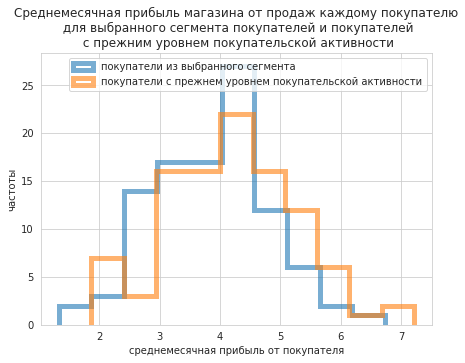

In [108]:
# построим гисторграммы для сегментной выборки и выборки покупателей с прежним уровнем активности
ax = segment_high_promo['прибыль'].plot(kind='hist', histtype='step', grid=True,
                                        bins=10, linewidth=5, alpha = 0.6,
                                        figsize = (7, 5),
                                        label = 'покупатели из выбранного сегмента',
                                        legend=True)

previous_level_buyers['прибыль'].plot(kind='hist', histtype='step', grid=True,
                                      bins=10, linewidth=5, alpha = 0.6,
                                      figsize = (7, 5), ax=ax,
                                      label='покупатели с прежнем уровнем покупательской активности',
                                      legend=True)

plt.title('Среднемесячная прибыль магазина от продаж каждому покупателю\n для выбранного сегмента покупателей и покупателей\n с прежним уровнем покупательской активности')
plt.xlabel('среднемесячная прибыль от покупателя')
plt.ylabel('частоты')
plt.show()

**Выводы**

На текущем этапе мы выбрали для исследования сегмент клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности. Долю покупок по акции мы определили выше 0.9 (т.е. более 90%), а вероятность снижения покупательской активности - выше 70%. В сегмент попал 101 покупатель, из них для 100 покупательская активность снизилась, и лишь для одного сохраняет прежний уровень.

Мы сравнили выбранный сегмент с выборкой из пользователей с прежним уровнем покупательской активности точно такого же размера по наиболее значимым признакам для лучшей прогнозной модели. Мы посмотрели как различается распределение значений по двум выборкам, средние и медианные значения. А также сопоставили прибыли, которые приносят компании обе выбранные группы пользователей. Мы видим разницу в прибыли, которую приносит один покупатель из выбранного сегмента и покупатель с прежним уровнем покупательской активности. Среднее значение прибыли в выбранном сегменте - 3.862, а среднее значение прибыли от покупателей с прежним уровнем покупательской активности - 4.186. Итого выходит, что в среднем покупатель из выбранного сегмента даёт компании примерно на 7.7% меньше прибыли, которую мог бы принести покупатель с прежнем уровнем активности. Такая потеря может быть существенной для компании, а в будущем потери прибыли могут быть ещё выше, если не принять меры.

Для компании основная проблема покупателей из выбранного сегмента, в том что они действуют очень узконаправленно: отслеживают и затем покупают зачастую только товары по акциям, т.е. товары исключительно по сниженной цене, и кроме того в среднем просматривают меньше категорий товаров и меньше страниц на сайте, проводят меньше времени на сайте по сравнению с пользователям, чей уровень покупательской активности остался на прежнем уровне. Медианное значение кол-ва просматриваемых категорий за один визит (признак `средний_просмотр_категорий_за_визит`) для выбранного сегмента покупателей - 3, а для выборки покупателей с прежним уровнем покупательской активности - 4. Также мы видим, что у покупателей из выбранного сегмента сравнительно непопулярны категории товаров - "Техника для красоты и здоровья" и "Мелкая бытовая техника и электроника". По всем пользователям эти категории товара как наиболее популярные занимают гораздо большую долю среди всех популярных категорий. Медианные значения времени, проведенного на сайте, для выбранного сегмента покупателей составляют 10 минут для предыдущего месяца и 11 для текущего месяца (признаки `минут_за_предыдущий_месяц` и `минут_за_текущий_месяц`). А для выборки покупателей с прежним уровнем покупательской активности медианные значения времени, проведенного на сайте, составляют 14 минут для предыдущего и текущего месяцев. Медианное значение просматриваемых на сайте (признак `страниц_за_визит`) за один визит для выбранного сегмента покупателей составляют 5, тогда как для выборки покупателей с прежним уровнем покупательской активности 10. Медианное среднемесячное значение маркетинговых коммуникаций компании (признак `маркет_актив_6_мес`), которое приходилось на покупателя из сегментной группы за последние 6 месяцев составляет 3.9, для выборки покупателей с прежним уровнем покупательской активности - 4.4.

Также для сегментной группы покупателей в среднем характерно более высокое значение неоплаченных товаров в корзине за последние 3 месяца (признак `неоплаченные_продукты_штук_квартал`). Медианное значение признака для сегментной группы - 4, а для группы покупателей с прежним уровнем покупательской активности - 2.  

Для увеличения покупательской активности выбранного сегмента мы рекомендуем сделать следующие шаги. Чаще при просмотре страниц на сайте предлагать пользователям подборки рекомендуемых товаров (не только по акциям, новинки не по акциям) из разных категорий, в том числе из тех, которые пользователь просматривает реже других. Предлагать пользователю посмотреть на другие товары из рекомендуемой подборки, когда пользователь переходит к оплате товара в корзине. Через рассылку сообщений делать таким пользователям предложение подписаться на новости о всех новых акциях и поступлениях товаров в выбранных категориях. Периодически присылать пользователям напоминания о неоплаченных товарах в корзине и заодно предлагать другие товары из выбранных категорий.

## Общий вывод 

Для интернет-магазина «В один клик», который столкнуля с проблемой снижения активности, нам была поставлена задача разработать оптимальную модель, которая предсказывает вероятность снижения покупательской активности, и которую можно использовать для прогноза покупательской активности на следующие 3 месяца. Кроме того, необходимо выделить по меньшей мере один сегмент покупателей, проанализировать его сделать для магазина предложения, как увеличить покупательскую активность для выбранного сегмента.

Мы выгрузили четыре файла с таблицами и сохранили данные каждой из них в отдельные датафреймы, в которых представленные следующие данные: данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении; данные о выручке, которую получает магазин с покупателя за каждый месяц из 3-х; данные о времени (в минутах), которое покупатель провёл на сайте в течение текущего либо предыдущего месяца; данные о среднемесячной прибыли, которую приносит магазину каждый покупатель. На этапе предобработки мы проверили пропуски, наличие дублей, правильность типа данных. Пропусков и явных дублей в данных не было обнаружено. Для устранения неявных дублей и для удобства дальнейшей работы мы исправили опечатки. После этого мы отобрали клиентов с покупательской активностью не менее трёх месяцев, удалив клиентов с нулевыми покупками хотя бы в одном из трех месяцев. Мы также заменили аномально высокое значение по выручке от одного клиента на медианное значение за тот же период. 

После завершения исследовательского анализа данных мы провели объединение первых трёх датафреймов для того чтобы использовать эти данные для дальнейшего моделирования. Предварительно мы преобразовали датафреймы с данными о выручке и о потрачененном на сайте времени, так чтобы данные за каждый из представленных периодов были выведены в отдельных столбцах (а не в одном по всем периодам, как в исходных данных).

Мы провели корреляционный анализ всех признаков с помощью коэффициента корреляции Фи, который позволяет считать коэффициент корреляции как для количественных, так и для категорийных переменных. Матрица корреляции показала признаки, которые сильнее всего связаны с целевым признаком `покупательской активности`: кол-во просмотренных страниц за визит (`страниц_за_визит`) и заметную корреляционную связь с признаками времени, проведенном на сайте (`минут_за_текущий_период`, `минут_за_предыдущий_период`, `маркет_актив_6_мес`, `акционные_покупки`, `средний_просмотр_категорий_за_визит`, `выручка_за_предпредыдущий_месяц`. Наиболее высокая корелляционная связь наблюдается между признками `выручка_за_текущий_месяц` и `выручка_за_предыдущий_месяц` - значение коэффициента 0.84. Коэффициент меньший 0.9 можно трактовать как отсустутствие мультиколлинеарности. Мы дополнительно посчитали коэффициент инфляции дисперсии (VIF) для всех количетенных признаков и получили наиболее высокий коэффициент для признака `выручка_за_предыдущий_месяц` 4.24. Значения выше 4 могут говорить о наличии существенной мультуколлинеарности. Дополнительно мы посмотрели зависимости между целевым признаком и признаками с заметной и высокой корреляцией на диаграммах расеяния. И также посмотрели на диаграммах зависимости между выручками за разные периоды и сделали вывод, что признак `выручка_за_предыдущий_месяц` линейно связан с признаком `выручка_за_текущий_месяц`, поэтому мы решили исключить признак `выручка_за_предыдущий_месяц` из дальнейшего моделирования.

Мы провели поиск оптимальной модели, применив пайплайны. Для решения мы использовать один общий пайплайн для всех моделей и инструмент подбора гиперпараметров с помощью GridSearchCV. Предварительно мы отобрали признаки для кодирования и масштабирования и кодировали целевой признак с помощью метода LabelEncoder(). Затем мы создали пайплайн для кодирования признаков методом OneHotEncoder(). На следующем шаге мы создали общий пайплайн для подготовки данных, включив в него пайплайны для кодирования и скалер для масштабирования данных. После этого мы создали итоговый пайплайн для решения задачи. Для поиска решения мы задали словари с гиперпараметрами для четырех моделей: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и SVC(). Для каждой модели мы задали гипермапарметры, применимые для указанной модели. Кроме того, для всех четырех моделей мы установили подбор оптимального метода масштабирования количественных признаков - StandardScaler() и MinMaxScaler(). В заключении мы запустили оптимизацию гиперпараметров с помощью селектора GridSearchCV, в который включили заданный словарь гиперпараметров, тип кросс-валидации (задали значение 5) и метрику для оценки качества обученных моделей. Мы выбрали для оценки качества моделей метрику 'roc-auc'. Эта метрика отлично подходит для решения задачи бинарной классификации и учитывает работу модели при всех возможных значениях порогов для классификации.

После применения поиска лучшей модели мы обучили её на тренировочной выборке и затем вывели ёё параметры. В результате мы получили, что лучшая модель для решения задачи классификации пользователей по покупательской активности - это модель опорных векторов SVC(probability=True, random_state=42) с оптимальными парметрами C=2, kernel='poly' и масштабированием StandardScaler(). Значение метрики ROC_AUC для лучшей найденной модели на кросс-валидационной выборке - 0.916, а на тестовой выборке значение ROC_AUC 0.919.

С помощью метода SHAP мы определили значимость признаков для лучшей модели. В результате для каждого признака, используемого моделью, было посчитано значение Шепли. Мы визуализировали общий вклад признаков в прогнозы модели - средние SHAP-значения признака по всем наблюдениям. Наименее значимыми для выбранной лучшей модели являются признаки `популярная_категория`, `тип_сервиса` и `разрешить_сообщать`, вклад этих признаков на значение целевого признака `покупательская_активность` равен нулю или чуть выше. Также мы определили признаки, которые сильнее всего влияют на целевой признак - `страниц_за_визит`, `минут_за_предыдущий_месяц`, `минут_за_текущий_месяц`, `акционные_покупки`. Для признака `страниц_за_визит` среднее SHAP-значение составляет +0.1, для признака `минут_за_предыдущий_месяц` — +0.08, для признака `минут_за_текущий_месяц` — +0.07, для признака `акционные_покупки` — +0.07.

Для следующего этапа исследования мы выбрали сегмент клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности. Долю покупок по акции мы определили выше 0.9 (т.е. более 90%), а вероятность снижения покупательской активности - выше 70%. В сегмент попали 101 покупатель, из них для 100 покупательская активность снизилась, и лишь для одного сохраняет прежний уровень. Мы сравнили выбранный сегмент с выборкой из пользователей с прежним уровнем покупательской активности точно такого же размера по наиболее значимым признакам для лучшей прогнозной модели. Мы посмотрели как различается распределение значений по двум выборкам, средние и медианные значения. А также сопоставили прибыли, которые приносят компании обе выбранные группы пользователей.

Для увеличения покупательской активности выбранного сегмента мы рекомендуем сделать следующие шаги:

- Предлагать пользователям подборки рекомендуемых товаров (не только по акциям, новинки не по акциям) из разных категорий, в том числе из тех, которые пользователь просматривает реже других; 

- Предлагать пользователю посмотреть на другие товары из рекомендуемой подборки в моменте, когда пользователь переходит к оплате товара в корзине. 

- Через рассылку сообщений делать таким пользователям предложение подписаться на новости о всех новых акциях и поступлениях товаров в выбранных категориях. 

- Периодически присылать пользователям напоминания о неоплаченных товарах в корзине и заодно предлагать другие товары из выбранных категорий.
